# Choice-Stability Stopping Study

**What this notebook produces.** An evaluation of a new *decision-stability*
stopping criterion for `VectorizedModel`: stop when **every** agent's chosen
theory (greedy `argmax` of its credence) has been unchanged for the last `W`
steps — equivalently, no agent has crossed the 0.5 decision boundary in the last
`W` steps. It targets the false-convergence / theory-flip failure mode of the
tolerance rule (see `STOPPING_CONDITION_ANALYSIS.md` §3.1). Companion to
`CHOICE_STABILITY_STOPPING_PLAN.md`.

Five studies, run on **three** citation networks (PUD, Tobacco, Ego):

- **Study 1 — Grid (record-once).** For `uncertainty × n_experiments × network`,
  run each seed **once** (native stop at the largest window, recording flips) and
  derive the stop step + truth share for **every** window `W ∈ {100,500,1000}`
  offline. This is the core study, so it runs at **2× the base replicate count**
  (`CS_GRID_N_RUNS = 2 × CS_N_RUNS`) and records per-combo wall-clock cost.
- **Study 2 — Runtime & step-count cost.** How *expensive* is this criterion?
  Stop-step distributions per window, measured throughput (steps/s), and a
  projected wall-clock budget for a full-scale study. This is the deciding
  factor for adopting the criterion.
- **Study 3 — Belief-dynamics trajectories.** Mean truth share and max absolute
  belief change vs step (mirroring `A_100k_Stopping_Study.ipynb`), showing what
  the run looks like at the moment choice-stability fires.
- **Study 4 — Regression analysis.** OLS testing **H1′** (steps driven by window,
  uncertainty, n_experiments) and **H2′** (truth share driven by uncertainty and
  ~invariant to window — the headline prediction).
- **Study 5 — Comparison.** Choice-stability vs tolerance stopping on shared
  seeds: stop step, truth share, and **post-stop flip rate** after resuming.

Set `SMOKE_TEST = True` for a fast Restart-and-Run-All; set it `False` on Colab
for the full grid.

# Setup

In [83]:
# ── Environment switch + master parameters (single source of truth) ──────────
# RUNNING_LOCALLY=True  → run on a laptop from the repo (no clone/pip/Drive).
# RUNNING_LOCALLY=False → Colab: force-fresh clone, pip install, mount Drive.
import os, sys, subprocess, shutil
from pathlib import Path

RUNNING_LOCALLY = False
SMOKE_TEST      = False          # True → fewer seeds/combos (NOT shorter runs)
RERUN           = False         # True → DELETE this run tag's datasets, regenerate
MASTER_SEED     = 20260717

# RERUN=False (default) regenerates only what is MISSING — the resume behaviour.
# RERUN=True DELETES every file in RESULTS_DIR first, so the whole run tag is
# rebuilt from scratch. This is the supported way to force recomputation and to
# clear a checkpoint whose config/schema fingerprint no longer matches; it
# replaces renaming folders by hand in the Drive UI. Deletion is scoped to the
# RUN_TAG subdirectory ('smoke' or 'full') and is NOT recoverable — nothing is
# archived. Setting it True with RUN_TAG='full' discards hours of compute.

# Tiered compute budgets (smoke → laptop → cloud); see NOTEBOOK_WRITING_SKILL §14.
# The grid + comparison checkpoint to Drive after every combo/criterion and skip
# work already saved, so a disconnect resumes instead of restarting from zero.
#
# NOTE: SMOKE_TEST now shrinks only the GRID (seeds and combos), never the step
# budget. Shortening runs made smoke and full results incomparable and censored
# the stop-step distribution, which is the quantity this notebook exists to
# measure. Smoke is therefore no longer a seconds-long R&RA.
CS_N_RUNS   = 5 if SMOKE_TEST else (50 if RUNNING_LOCALLY else 250)
CS_MAX_STEPS = 100_000          # same ceiling in every setup

# Floor: never stop before this many steps, however stable choices look. Guards
# against stopping on transient early agreement and guarantees every recorded
# flip history spans at least this many steps, which the offline window sweep
# needs in order to derive larger windows honestly.
CS_MIN_STEPS = 10_000

# Study 1 (the grid) is the study this notebook exists to answer, so it gets
# TWICE the replicates of every other section — tighter CIs on the stop-step
# distribution, which is the quantity the adoption decision turns on.
CS_GRID_N_RUNS = 2 * CS_N_RUNS

# Snapshot cadence for the Study 3 trajectory plots. Must be fine enough that a
# typical run yields many snapshots before it stabilizes.
SNAPSHOT_INTERVAL = 500

# The choice-stability windows are DERIVED OFFLINE from one record-once run each.
# The SAME window set is used in EVERY setup (smoke and full) — a config that
# shrinks the windows to fit a short smoke run makes smoke and full results
# incomparable, and silently censors the stop-step distribution.
CS_WINDOWS = [100, 500, 1000]

print(f"RUNNING_LOCALLY={RUNNING_LOCALLY}  SMOKE_TEST={SMOKE_TEST}")
print(f"CS_N_RUNS={CS_N_RUNS}  CS_GRID_N_RUNS={CS_GRID_N_RUNS} (Study 1)")
print(f"CS_MAX_STEPS={CS_MAX_STEPS:,}  CS_MIN_STEPS={CS_MIN_STEPS:,}")
print(f"CS_WINDOWS={CS_WINDOWS}  SNAPSHOT_INTERVAL={SNAPSHOT_INTERVAL}")
assert CS_MIN_STEPS >= max(CS_WINDOWS), "min steps must cover the largest window"
if CS_MAX_STEPS < 10 * max(CS_WINDOWS):
    print(f"  [warn] CS_MAX_STEPS={CS_MAX_STEPS:,} is small relative to the "
          f"largest window ({max(CS_WINDOWS)}) — expect many runs to hit the cap "
          f"without stabilizing, which CENSORS the stop-step distribution and "
          f"makes the Study 2 runtime projection a lower bound only.")


RUNNING_LOCALLY=False  SMOKE_TEST=False
CS_N_RUNS=250  CS_GRID_N_RUNS=500 (Study 1)
CS_MAX_STEPS=100,000  CS_MIN_STEPS=10,000
CS_WINDOWS=[100, 500, 1000]  SNAPSHOT_INTERVAL=500


In [84]:
# Force-fresh clone + deps (Colab only). Uses subprocess/os.chdir (not %/!) so
# the RUNNING_LOCALLY guard actually holds — see NOTEBOOK_WRITING_SKILL §5–6.
if not RUNNING_LOCALLY:
    # IDEMPOTENT: anchor on an absolute base, never the cwd. Resolving the repo
    # name relative to the cwd meant a second run cloned INSIDE the first clone
    # and chdir'd deeper each time (/content/e_network_inequality/e_network_...),
    # leaving stale clone roots on sys.path.
    COLAB_BASE = Path('/content')
    os.chdir(COLAB_BASE)
    repo_dir = COLAB_BASE / 'e_network_inequality'
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    subprocess.run(['git', 'clone', '-b', 'main',
                    'https://github.com/IgnacioOQ/e_network_inequality'], check=True)
    subprocess.run(['pip', 'install', '-q', 'dill'], check=True)
    os.chdir(repo_dir)

# Locate the project root (the inner dir containing model/) and put it on sys.path.
if RUNNING_LOCALLY:
    # This notebook lives in model/convergence_analysis/stopping_condition/.
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'model').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)
sys.path.insert(0, os.getcwd())
print("Working dir:", os.getcwd())

Working dir: /content/e_network_inequality


In [85]:
# Explicit imports (no wildcards from external libs).
import itertools, pickle, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from functools import partial
from multiprocessing import Pool, cpu_count
from numpy.random import SeedSequence
from tqdm.auto import tqdm

from model.vectorized_model import VectorizedModel
from model.vectorized_simulation_functions import run_vectorized_simulation_with_params

num_cores = cpu_count()
print(f"Available CPU cores: {num_cores}")

Available CPU cores: 8


In [86]:
# Output directory — one path constant per role, created once.
# CONFIG-SCOPED: smoke and full-scale runs write to SEPARATE subdirectories, so
# the resume logic can never mistake one for the other. Results predating this
# split stay untouched in the parent directory.
RUN_TAG = 'smoke' if SMOKE_TEST else 'full'
if RUNNING_LOCALLY:
    RESULTS_DIR = Path('model/convergence_analysis/stopping_condition') / RUN_TAG
else:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = (Path('/content/drive/My Drive/Colab Projects/Data Driven ABMs/'
                        'Data Sets/choice_stability_study') / RUN_TAG)
RESULTS_DIR = Path(RESULTS_DIR)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run tag: {RUN_TAG}")
print("Results dir:", RESULTS_DIR)

if RERUN:
    # Scoped hard: only ever the RUN_TAG subdirectory, never its parent. Without
    # this guard a mis-set RESULTS_DIR would delete the whole study tree.
    assert RESULTS_DIR.name in ('smoke', 'full'), \
        f"RERUN refuses to delete {RESULTS_DIR} — expected a 'smoke'/'full' dir"
    doomed = sorted(p for p in RESULTS_DIR.iterdir() if p.is_file())
    print(f"\n  RERUN=True — deleting {len(doomed)} file(s); NOT archived:")
    for p in doomed:
        print(f"    rm {p.name}")
        p.unlink()
    print(f"  '{RUN_TAG}' datasets will be regenerated from scratch.\n")

def save_fig(name, dpi=150):
    plt.savefig(RESULTS_DIR / name, dpi=dpi, bbox_inches='tight')
    plt.show()

def save_csv(df, name):
    path = RESULTS_DIR / name
    df.to_csv(path, index=False)
    print(f"  Saved: {path} ({len(df)} rows)")
    return path

def read_csv_safe(path, columns):
    """Read a checkpoint CSV, tolerating a missing OR column-less file.

    A run in which every combo was skipped writes an empty DataFrame, and
    `pd.DataFrame([]).to_csv()` produces a file with no columns that
    `pd.read_csv` rejects with EmptyDataError. Treat that as 'no checkpoint'
    rather than crashing the next run."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(columns=columns)
    try:
        df = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print(f"  [warn] {path.name} is empty — treating as no checkpoint")
        return pd.DataFrame(columns=columns)
    return df if len(df.columns) else pd.DataFrame(columns=columns)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Run tag: full
Results dir: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full

  RERUN=True — deleting 36 file(s); NOT archived:
    rm all_networks_choice_stability_trajectories.png
    rm ego_choice_stability.csv
    rm ego_choice_stability_boxplot.png
    rm ego_choice_stability_config.json
    rm ego_choice_stability_cost.csv
    rm ego_choice_stability_steps_lines.png
    rm ego_choice_stability_summary.csv
    rm ego_choice_stability_trajectories.png
    rm ego_choice_stability_truth_share_lines.png
    rm network_degree_distributions.png
    rm network_statistics.csv
    rm pud_choice_stability.csv
    rm pud_choice_stability_boxplot.png
    rm pud_choice_stability_config.json
    rm pud_choice_stability_cost.csv
    rm pud_choice_stability_steps_lines.png
    rm pud_choice_stability_summary.csv
    rm pud_cho

In [87]:
def offline_stop(flip_history, window, max_steps, min_steps=0):
    """Derive (stop_step, truth_share, stabilized) for a window from a
    record_choice_flips history [(step, truth_share), ...] — a baseline entry
    at run start plus one per step where >=1 agent flipped. Truth share is
    constant between flips, so the stop is fixed by the first flip-free
    interval long enough to contain `window` stable steps at or after
    `min_steps`. If none exists, the run did not stabilize within max_steps.

    The floor matters: without it a run that looks stable at step 300 stops
    there, so the same `min_steps` applied to the native run must be applied
    here, or the derived and native stops disagree.

    NOTE the record-once run stops natively at the LARGEST window, so its history
    contains every flip needed to derive all smaller windows (proven equivalent
    to per-window native runs in test_stopping_conditions.py)."""
    steps = [s for s, _ in flip_history] + [max_steps]
    shares = [t for _, t in flip_history]
    for i in range(len(flip_history)):
        # Earliest stop inside this flip-free interval that satisfies BOTH the
        # window and the floor; valid only if no flip occurs before it.
        candidate = max(steps[i] + window, min_steps)
        if candidate <= steps[i + 1]:
            return candidate, shares[i], True
    return max_steps, (shares[-1] if shares else np.nan), False


# Study 0: Load Networks

Load the three citation networks and report their structural statistics. These
are **directed** graphs, and the structure matters for reading every later
result: a network's size sets the per-step cost (Study 2), while its degree
distribution and source-node count shape how long agents keep flipping before
choice-stability can fire (Study 1).

In [88]:
def load_indexed(path):
    with open(path, 'rb') as f:
        G = pickle.load(f)
    G = nx.relabel_nodes(G, {n: i for i, n in enumerate(G.nodes())})
    print(f"  {os.path.basename(path)}: {G.number_of_nodes()} nodes, "
          f"{G.number_of_edges()} edges, "
          f"{'directed' if G.is_directed() else 'undirected'}")
    return G

print("Loading networks:")
G_pud     = load_indexed('./networks/citation_data/pud_network.pkl')
G_tobacco = load_indexed('./networks/citation_data/tobacco_network.pkl')
G_ego     = load_indexed('./networks/citation_data/ego_network.pkl')

# (label, file_prefix, graph, plot_color) — the single source of truth for the
# network axis; every study iterates or indexes into this list.
NETWORKS = [("PUD",     "pud",     G_pud,     '#2980b9'),
            ("Tobacco", "tobacco", G_tobacco, '#e74c3c'),
            ("Ego",     "ego",     G_ego,     '#27ae60')]

Loading networks:
  pud_network.pkl: 90 nodes, 160 edges, directed
  tobacco_network.pkl: 289 nodes, 1229 edges, directed
  ego_network.pkl: 503 nodes, 2933 edges, directed


In [89]:
# ── Network statistics table ────────────────────────────────────────────────
# Reuses utils.network_utils.network_statistics (average degree, degree Gini,
# average clustering) and adds the size/connectivity fields this study needs.
from utils.network_utils import network_statistics

def describe_network(G, label):
    directed = G.is_directed()
    n, m = G.number_of_nodes(), G.number_of_edges()
    stats = network_statistics(G, directed=directed)
    in_deg  = np.array([d for _, d in G.in_degree()]) if directed else None
    out_deg = np.array([d for _, d in (G.out_degree() if directed else G.degree())])
    # Sources (in-degree 0) receive no neighbour evidence, and isolates are
    # disconnected entirely — both keep updating on their own experiments, so
    # they bear directly on how long agents keep flipping.
    row = {
        "network": label,
        "nodes": n,
        "edges": m,
        "directed": directed,
        "density": round(nx.density(G), 4),
        "mean_out_degree": round(float(out_deg.mean()), 2),
        "max_out_degree": int(out_deg.max()),
        "mean_in_degree": round(float(in_deg.mean()), 2) if directed else None,
        "max_in_degree": int(in_deg.max()) if directed else None,
        "degree_gini": round(stats["degree_gini_coefficient"], 3),
        "avg_clustering": round(stats["approx_average_clustering_coefficient"], 3),
        "sources_in_deg_0": int((in_deg == 0).sum()) if directed else None,
        "isolates": int(len(list(nx.isolates(G)))),
    }
    # Weak connectivity: the undirected reachability skeleton.
    comps = (list(nx.weakly_connected_components(G)) if directed
             else list(nx.connected_components(G)))
    row["components"] = len(comps)
    row["largest_component_frac"] = round(max(len(c) for c in comps) / n, 3)
    return row

net_stats = pd.DataFrame([describe_network(G, lbl) for lbl, _, G, _ in NETWORKS])
print("── Network statistics ──")
print(net_stats.to_string(index=False))
save_csv(net_stats, "network_statistics.csv")
try:
    display(net_stats)
except NameError:
    pass

── Network statistics ──
network  nodes  edges  directed  density  mean_out_degree  max_out_degree  mean_in_degree  max_in_degree  degree_gini  avg_clustering  sources_in_deg_0  isolates  components  largest_component_frac
    PUD     90    160      True   0.0200             1.78              19            1.78              6        0.725           0.164                21         0           1                     1.0
Tobacco    289   1229      True   0.0148             4.25              93            4.25             29        0.761           0.235                53         0           1                     1.0
    Ego    503   2933      True   0.0116             5.83             394            5.83             41        0.920           0.594                 1         0           1                     1.0
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/network_statistics.csv (3 rows)


,network,nodes,edges,directed,density,mean_out_degree,max_out_degree,mean_in_degree,max_in_degree,degree_gini,avg_clustering,sources_in_deg_0,isolates,components,largest_component_frac
0,PUD,90,160,True,0.0200,1.78,19,1.78,6,0.725,0.164,21,0,1,1.0
1,Tobacco,289,1229,True,0.0148,4.25,93,4.25,29,0.761,0.235,53,0,1,1.0
2,Ego,503,2933,True,0.0116,5.83,394,5.83,41,0.920,0.594,1,0,1,1.0


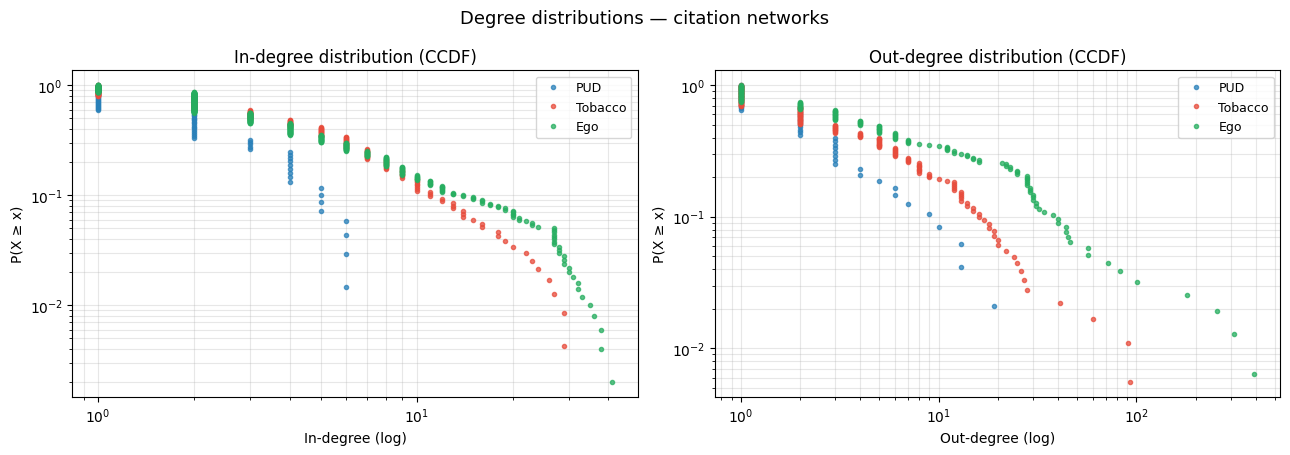

In [90]:
# ── Degree distributions (log-log CCDF) ─────────────────────────────────────
# A heavier tail means a few high-in-degree agents dominate what everyone sees,
# which is what drives the cross-network differences in later studies.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for label, _, G, color in NETWORKS:
    for ax, (deg_view, name) in zip(axes, [(G.in_degree(), "In-degree"),
                                           (G.out_degree(), "Out-degree")]):
        d = np.array([v for _, v in deg_view])
        d = np.sort(d[d > 0])
        if d.size == 0:
            continue
        ccdf = 1.0 - np.arange(d.size) / d.size
        ax.plot(d, ccdf, marker='.', linestyle='none', color=color,
                alpha=0.75, label=label)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(f"{name} (log)"); ax.set_ylabel("P(X ≥ x)")
        ax.set_title(f"{name} distribution (CCDF)")
        ax.grid(True, alpha=0.3, which='both')
for ax in axes:
    ax.legend(fontsize=9)
fig.suptitle("Degree distributions — citation networks", fontsize=13)
plt.tight_layout()
save_fig("network_degree_distributions.png")

# Study 1: Choice-Stability Grid (record-once)

Grid over `uncertainty × n_experiments`, on each of the three networks. Each seed
is run **once** with native `choice_stability_stopping` at the largest window plus
`record_choice_flips`; every window is then derived offline (`offline_stop`). The
window axis therefore costs no extra simulation.

This is the notebook's core study, so it runs `CS_GRID_N_RUNS = 2 × CS_N_RUNS`
replicates per combo. Records `steps`, `truth_share`, `stabilized`, and
`native_steps` per (run, window), plus a **per-combo cost row** (wall-clock,
total simulated steps, throughput) that Study 2 turns into a runtime projection.

In [91]:
# ── Study 1 — Config ─────────────────────────────────────────────────────────
CS_UNCERTAINTIES = [0.0001, 0.001, 0.005, 0.01]
CS_N_EXPERIMENTS = [100, 500, 1000]
if SMOKE_TEST:
    CS_UNCERTAINTIES = [0.001, 0.01]
    CS_N_EXPERIMENTS = [100, 500]
print("uncertainties:", CS_UNCERTAINTIES)
print("n_experiments:", CS_N_EXPERIMENTS)
print("windows (offline):", CS_WINDOWS)
print("runs/combo:", CS_N_RUNS, " max_steps:", CS_MAX_STEPS)

uncertainties: [0.0001, 0.001, 0.005, 0.01]
n_experiments: [100, 500, 1000]
windows (offline): [100, 500, 1000]
runs/combo: 250  max_steps: 100000


In [92]:
import json

# Columns are declared explicitly so an EMPTY result still writes a parseable
# (header-only) CSV instead of a zero-column file the next run cannot read.
GRID_COLS = ["n_experiments", "uncertainty", "window", "run", "steps",
             "truth_share", "stabilized", "native_steps",
             "steps_nofloor", "stabilized_nofloor"]
COST_COLS = ["network", "n_experiments", "uncertainty", "n_runs",
             "window_native", "wall_sec", "total_native_steps",
             "steps_per_sec", "sec_per_run", "num_cores"]


def _config_fingerprint():
    """The configuration a checkpoint was produced under.

    Two runs whose fingerprints differ must NEVER share a checkpoint. Without
    this, a 3k-step smoke run and a 100k-step full run silently merge: the
    smoke combos already exist in the full checkpoint, every combo is skipped,
    zero simulations execute, and the summaries/plots are then built from the
    other run's data under this run's label."""
    return {"schema": 2,          # bump when the CSV columns change
            "smoke": bool(SMOKE_TEST),
            "windows": sorted(int(w) for w in CS_WINDOWS),
            "max_steps": int(CS_MAX_STEPS),
            "min_steps": int(CS_MIN_STEPS),
            "n_runs": int(CS_GRID_N_RUNS),
            "n_experiments": sorted(int(n) for n in CS_N_EXPERIMENTS),
            "uncertainties": sorted(float(u) for u in CS_UNCERTAINTIES)}


def _check_fingerprint(output_prefix):
    """Stamp the config on first use; refuse to resume when it has changed."""
    fp_path = RESULTS_DIR / f"{output_prefix}_choice_stability_config.json"
    current = _config_fingerprint()
    if fp_path.exists():
        saved = json.loads(fp_path.read_text())
        if saved != current:
            raise RuntimeError(
                "Checkpoint config mismatch — refusing to merge runs.\n"
                f"  dir:     {RESULTS_DIR}\n"
                f"  saved:   {saved}\n"
                f"  current: {current}\n"
                "Point RESULTS_DIR at a fresh directory, or move the existing "
                "checkpoint aside before re-running.")
    else:
        fp_path.write_text(json.dumps(current, indent=2))


def run_choice_stability_grid(network, network_label, output_prefix,
                              master_seed=MASTER_SEED):
    """Run the record-once grid for one network, checkpointing after each combo.

    Writes two CSVs: the per-(run, window) results and a per-combo COST table
    (wall-clock + simulated steps) that Study 2 uses to project runtime, plus a
    config fingerprint that prevents cross-config checkpoint reuse.
    """
    _check_fingerprint(output_prefix)

    csv_path  = RESULTS_DIR / f"{output_prefix}_choice_stability.csv"
    cost_path = RESULTS_DIR / f"{output_prefix}_choice_stability_cost.csv"
    combos = list(itertools.product(CS_N_EXPERIMENTS, CS_UNCERTAINTIES))
    W_max = max(CS_WINDOWS)
    expected_per_combo = CS_GRID_N_RUNS * len(CS_WINDOWS)

    done_df = read_csv_safe(csv_path, GRID_COLS)
    if len(done_df):
        print(f"  [{network_label}] resuming from checkpoint ({len(done_df)} rows)")
    cost_rows = read_csv_safe(cost_path, COST_COLS).to_dict("records")

    def _combo_mask(df, n_exp, unc):
        if df.empty:
            return pd.Series([], dtype=bool)
        return (df["n_experiments"] == n_exp) & np.isclose(df["uncertainty"], unc)

    def _combo_done(df, n_exp, unc):
        m = _combo_mask(df, n_exp, unc)
        return (not df.empty) and int(m.sum()) >= expected_per_combo

    combo_seqs = SeedSequence(master_seed).spawn(len(combos))   # one per combo
    rows = done_df.to_dict("records")
    t_start = time.time()
    print(f"  [{network_label}] {len(combos)} combos × {CS_GRID_N_RUNS} runs = "
          f"{len(combos)*CS_GRID_N_RUNS:,} simulations (all windows derived offline)")

    with tqdm(list(enumerate(combos)), desc=f"[{network_label}] combos",
              unit="combo") as pbar:
        for idx, (n_exp, unc) in pbar:
            if _combo_done(done_df, n_exp, unc):
                pbar.set_postfix(skip=f"n_exp={n_exp} unc={unc}")
                continue
            # A PARTIALLY-filled combo (e.g. a checkpoint written under a smaller
            # CS_GRID_N_RUNS) is dropped before re-running, so re-running never
            # appends a second copy of the same combo.
            if not done_df.empty:
                stale = _combo_mask(done_df, n_exp, unc)
                if int(stale.sum()) > 0:
                    print(f"    dropping {int(stale.sum())} partial rows for "
                          f"n_exp={n_exp} unc={unc} before re-running")
                    keep = done_df[~stale]
                    done_df = keep
                    rows = keep.to_dict("records")
                    cost_rows = [c for c in cost_rows
                                 if not (c["n_experiments"] == n_exp
                                         and np.isclose(c["uncertainty"], unc))]

            child_seeds = [int(s.generate_state(1)[0])
                           for s in combo_seqs[idx].spawn(CS_GRID_N_RUNS)]
            param_dicts = [{"network": network, "n_experiments": n_exp,
                            "uncertainty": unc, "seed": cs} for cs in child_seeds]

            # Native stop at the largest window + record flips → one run per seed.
            wrapper = partial(
                run_vectorized_simulation_with_params,
                tolerance_stopping=False,
                choice_stability_stopping=True,
                choice_stability_window=W_max,
                choice_stability_min_steps=CS_MIN_STEPS,
                record_choice_flips=True,
                number_of_steps=CS_MAX_STEPS,
                show_bar=False, agent_type="beta",
            )
            t0 = time.time()
            with Pool(num_cores) as pool:
                results = list(tqdm(pool.imap_unordered(wrapper, param_dicts),
                                    total=CS_GRID_N_RUNS, leave=False,
                                    desc=f"  n_exp={n_exp} unc={unc:.4f}"))
            wall = time.time() - t0

            # Cost row: wall-clock is for CS_GRID_N_RUNS runs spread over
            # num_cores, so throughput is an AGGREGATE machine rate (not
            # per-core). Study 2 projects with it on the same core count.
            native_total = int(sum(r["convergence_step"] for r in results))
            cost_rows.append({
                "network": network_label, "n_experiments": n_exp,
                "uncertainty": unc, "n_runs": CS_GRID_N_RUNS,
                "window_native": W_max, "wall_sec": wall,
                "total_native_steps": native_total,
                "steps_per_sec": native_total / wall if wall > 0 else np.nan,
                "sec_per_run": wall / CS_GRID_N_RUNS, "num_cores": num_cores,
            })

            for run_idx, r in enumerate(results):
                flips = r["choice_flip_history"]
                for W in CS_WINDOWS:
                    # TWO stops from the SAME flip history — no extra simulation:
                    #   steps         with the CS_MIN_STEPS floor — the policy
                    #                 you would actually deploy.
                    #   steps_nofloor the criterion's natural behaviour. The
                    #                 floor is binding for most runs (median
                    #                 stop sits exactly on it), so H1' — does
                    #                 the window drive stop time? — must be
                    #                 tested on THIS series, or the floor
                    #                 flattens the very effect being measured.
                    stop, tshare, stab = offline_stop(flips, W, CS_MAX_STEPS,
                                                      min_steps=CS_MIN_STEPS)
                    stop_nf, _, stab_nf = offline_stop(flips, W, CS_MAX_STEPS,
                                                       min_steps=0)
                    rows.append({"n_experiments": n_exp, "uncertainty": unc,
                                 "window": W, "run": run_idx, "steps": stop,
                                 "truth_share": tshare, "stabilized": int(stab),
                                 "native_steps": r["convergence_step"],
                                 "steps_nofloor": stop_nf,
                                 "stabilized_nofloor": int(stab_nf)})
            # Checkpoint after every combo (only complete combos persist).
            done_df = pd.DataFrame(rows, columns=GRID_COLS)
            done_df.to_csv(csv_path, index=False)
            pd.DataFrame(cost_rows, columns=COST_COLS).to_csv(cost_path, index=False)
            pbar.set_postfix(last=f"{wall:.1f}s", rows=f"{len(rows):,}")

    print(f"  [{network_label}] Done — {len(rows)} rows in "
          f"{(time.time()-t_start)/60:.1f} min")

    df = pd.DataFrame(rows, columns=GRID_COLS)
    save_csv(df, f"{output_prefix}_choice_stability.csv")
    save_csv(pd.DataFrame(cost_rows, columns=COST_COLS),
             f"{output_prefix}_choice_stability_cost.csv")
    if df.empty:
        print(f"  [{network_label}] WARNING: no rows — every combo was skipped. "
              f"Downstream studies have nothing to analyse for this network.")
        return df
    summary = (df.groupby(["n_experiments", "uncertainty", "window"])
                 .agg(mean_steps=("steps", "mean"), std_steps=("steps", "std"),
                      mean_steps_nofloor=("steps_nofloor", "mean"),
                      mean_truth=("truth_share", "mean"),
                      std_truth=("truth_share", "std"),
                      stabilized_rate=("stabilized", "mean")).reset_index())
    save_csv(summary, f"{output_prefix}_choice_stability_summary.csv")
    _plot_grid(df, network_label, output_prefix)
    return df


In [93]:
def _plot_grid(df, network_label, output_prefix):
    # (a) Stop-time distribution per window (log scale) — false-convergence lens.
    plt.figure(figsize=(8, 5))
    data = [df[df.window == W]["steps"].values for W in CS_WINDOWS]
    plt.boxplot(data, positions=range(len(CS_WINDOWS)))
    plt.xticks(range(len(CS_WINDOWS)), [str(W) for W in CS_WINDOWS])
    plt.yscale('log'); plt.xlabel("Window W (flip-free steps)")
    plt.ylabel("Stop step (log)")
    plt.title(f"Choice-stability stop-time vs window — {network_label}")
    plt.grid(True, alpha=0.3, which='both')
    save_fig(f"{output_prefix}_choice_stability_boxplot.png")

    # (b) Window sensitivity: mean steps (should rise) and mean truth share
    #     (should stay ~flat — the H2' visual), faceted by n_experiments.
    for metric, ylab, logy in [("steps", "Mean stop step (log)", True),
                               ("truth_share", "Mean truth share", False)]:
        fig, axes = plt.subplots(1, len(CS_N_EXPERIMENTS), sharey=True,
                                 figsize=(5 * len(CS_N_EXPERIMENTS), 4.5))
        axes = np.atleast_1d(axes)
        colors = plt.cm.viridis(np.linspace(0, 0.9, len(CS_UNCERTAINTIES)))
        for ax, n_exp in zip(axes, CS_N_EXPERIMENTS):
            sub = df[df.n_experiments == n_exp]
            for unc, c in zip(CS_UNCERTAINTIES, colors):
                means = [sub[(sub.uncertainty == unc) & (sub.window == W)][metric].mean()
                         for W in CS_WINDOWS]
                ax.plot([str(W) for W in CS_WINDOWS], means, 'o-', color=c,
                        label=f"unc={unc}", linewidth=1.8, markersize=5)
            if logy: ax.set_yscale('log')
            else:    ax.set_ylim(0, 1)
            ax.set_title(f"n_experiments={n_exp}"); ax.set_xlabel("Window W")
            ax.grid(True, alpha=0.3)
            if ax is axes[0]: ax.set_ylabel(ylab)
        axes[-1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
        fig.suptitle(f"{ylab.split(' (')[0]} vs window — {network_label}")
        plt.tight_layout()
        save_fig(f"{output_prefix}_choice_stability_{metric}_lines.png")

In [94]:
# ── Checkpoint inventory (read-only) ─────────────────────────────────────────
# Answers "what state am I in?" WITHOUT running a simulation. Run this before
# the grid: it reports each network as UNSTARTED / PARTIAL / COMPLETE and warns
# when the checkpoint on disk was written under a different config or schema.
#
# Why this exists: the resume logic is otherwise only discoverable by TRIGGERING
# it. A fully-skipped grid prints "Done — 18000 rows in 0.0 min", which is
# indistinguishable from a run that failed to start, and a schema-bumped
# checkpoint surfaces only as a RuntimeError mid-run.
expected_rows = (len(CS_N_EXPERIMENTS) * len(CS_UNCERTAINTIES)
                 * CS_GRID_N_RUNS * len(CS_WINDOWS))
current_fp = _config_fingerprint()

print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"  run tag: {RUN_TAG}   expected rows/network: {expected_rows:,}")
print(f"  RERUN={RERUN}" + ("  (datasets were deleted above and are being rebuilt)" if RERUN else ""))
print()

for label, prefix, _G, _color in NETWORKS:
    csv_path = RESULTS_DIR / f"{prefix}_choice_stability.csv"
    fp_path = RESULTS_DIR / f"{prefix}_choice_stability_config.json"
    n_rows = len(read_csv_safe(csv_path, []))

    if n_rows == 0:
        state = "UNSTARTED"
    elif n_rows >= expected_rows:
        state = "COMPLETE — the grid cell will skip every combo (0 simulations)"
    else:
        state = f"PARTIAL ({n_rows / expected_rows:.0%})"
    print(f"  [{label:<7}] {n_rows:>7,} / {expected_rows:,} rows   {state}")

    if fp_path.exists():
        saved = json.loads(fp_path.read_text())
        if saved != current_fp:
            diff = {k: (saved.get(k, "<absent>"), current_fp.get(k, "<absent>"))
                    for k in set(saved) | set(current_fp)
                    if saved.get(k) != current_fp.get(k)}
            print(f"            [!] fingerprint MISMATCH — the grid will RAISE.")
            print(f"                differs on: {diff}")
            if saved.get("schema") != current_fp.get("schema"):
                print(f"                schema {saved.get('schema', 1)} -> "
                      f"{current_fp['schema']}: the CSV columns changed, so these "
                      f"rows CANNOT be reused. Quarantine the directory.")
    elif n_rows:
        print("            [!] rows present but no fingerprint file — provenance unknown")

# The fingerprint deliberately captures CONFIG, not provenance. A checkpoint
# written under a different master seed merges silently, so state it explicitly.
print()
print(f"NOTE: MASTER_SEED is NOT part of the fingerprint. Current MASTER_SEED="
      f"{MASTER_SEED}. A checkpoint produced under a different seed would be "
      f"merged without warning.")


RESULTS_DIR: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full
  run tag: full   expected rows/network: 18,000
  RERUN=True  (datasets were deleted above and are being rebuilt)

  [PUD    ]       0 / 18,000 rows   UNSTARTED
  [Tobacco]       0 / 18,000 rows   UNSTARTED
  [Ego    ]       0 / 18,000 rows   UNSTARTED

NOTE: MASTER_SEED is NOT part of the fingerprint. Current MASTER_SEED=20260717. A checkpoint produced under a different seed would be merged without warning.


## PUD Network

=== Choice-Stability Grid: PUD Network ===
  [PUD] 12 combos × 500 runs = 6,000 simulations (all windows derived offline)


[PUD] combos:   0%|          | 0/12 [00:00<?, ?combo/s]

  n_exp=100 unc=0.0001:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=100 unc=0.0010:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=100 unc=0.0050:   0%|          | 0/500 [00:00<?, ?it/s]

...

  n_exp=1000 unc=0.0001:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0010:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0050:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0100:   0%|          | 0/500 [00:00<?, ?it/s]

  [PUD] Done — 18000 rows in 70.7 min
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/pud_choice_stability.csv (18000 rows)
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/pud_choice_stability_cost.csv (12 rows)
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/pud_choice_stability_summary.csv (36 rows)


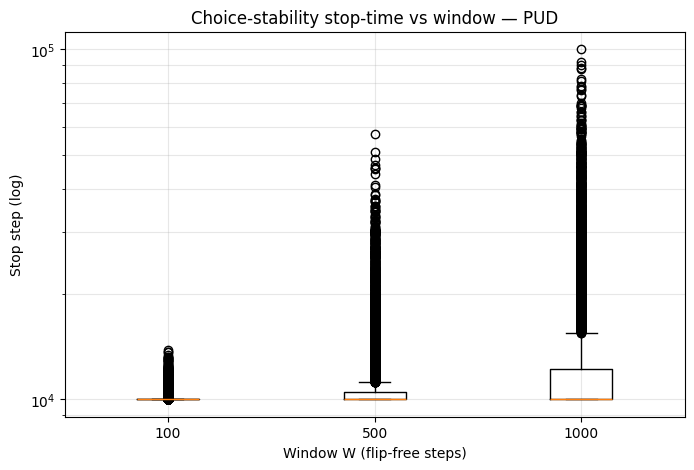

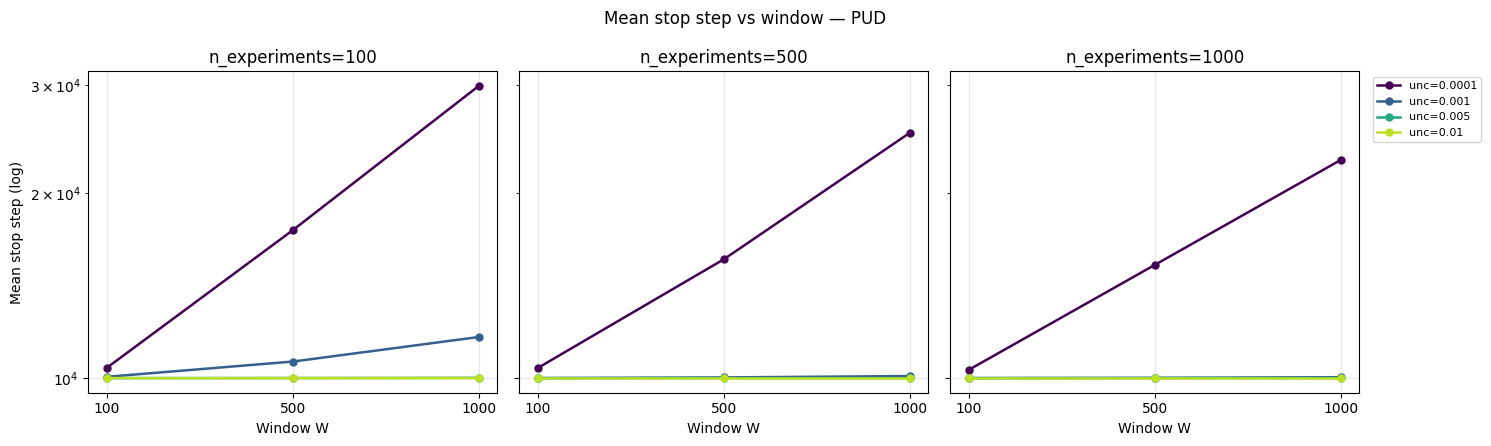

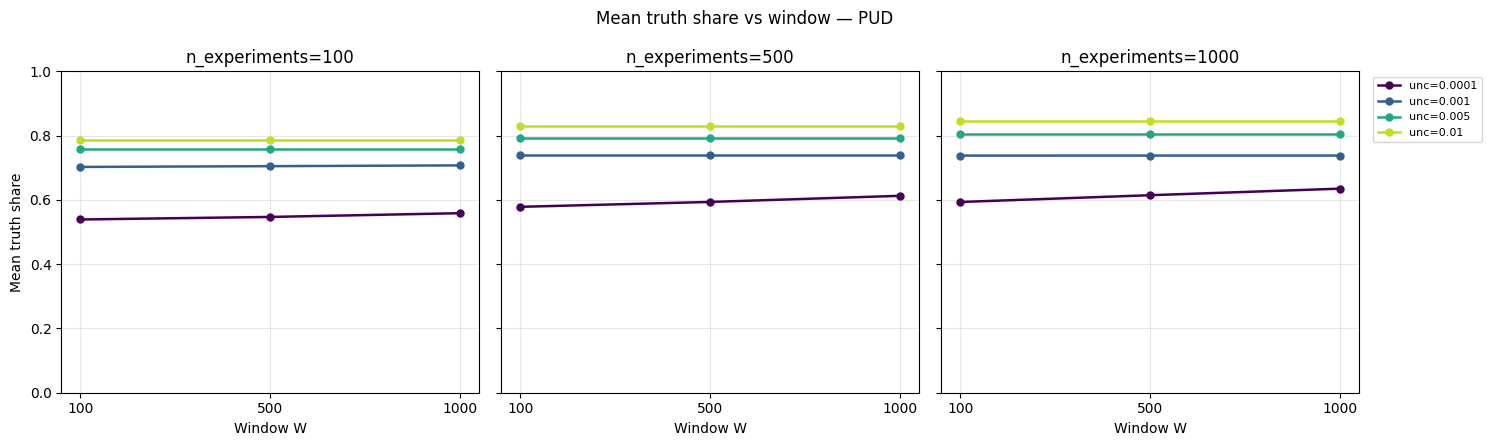

In [95]:
print("=== Choice-Stability Grid: PUD Network ===")
df_pud = run_choice_stability_grid(G_pud, "PUD", "pud")

## Tobacco Network

=== Choice-Stability Grid: Tobacco Network ===
  [Tobacco] 12 combos × 500 runs = 6,000 simulations (all windows derived offline)


[Tobacco] combos:   0%|          | 0/12 [00:00<?, ?combo/s]

  n_exp=100 unc=0.0001:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=100 unc=0.0010:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=100 unc=0.0050:   0%|          | 0/500 [00:00<?, ?it/s]

...

  n_exp=1000 unc=0.0001:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0010:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0050:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0100:   0%|          | 0/500 [00:00<?, ?it/s]

  [Tobacco] Done — 18000 rows in 179.7 min
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/tobacco_choice_stability.csv (18000 rows)
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/tobacco_choice_stability_cost.csv (12 rows)
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/tobacco_choice_stability_summary.csv (36 rows)


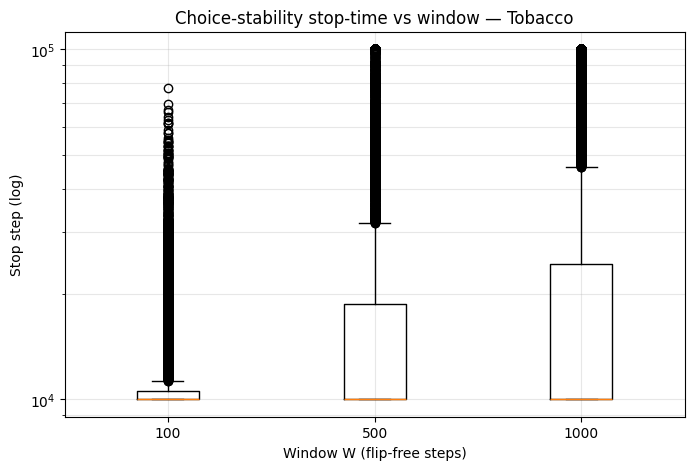

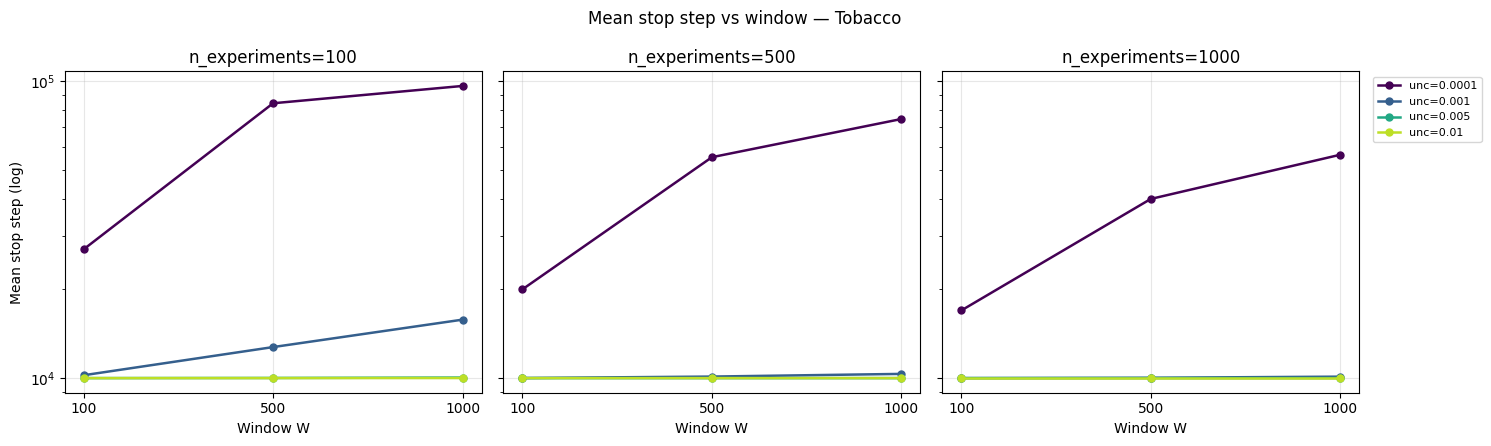

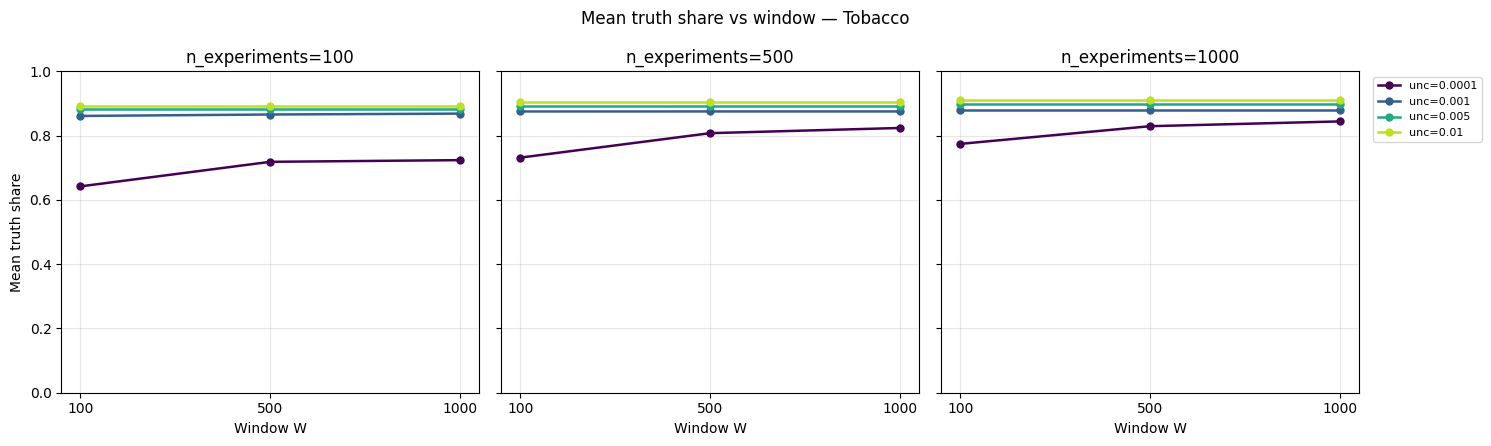

In [96]:
print("=== Choice-Stability Grid: Tobacco Network ===")
df_tobacco = run_choice_stability_grid(G_tobacco, "Tobacco", "tobacco")

## Ego Network

=== Choice-Stability Grid: Ego Network ===
  [Ego] 12 combos × 500 runs = 6,000 simulations (all windows derived offline)


[Ego] combos:   0%|          | 0/12 [00:00<?, ?combo/s]

  n_exp=100 unc=0.0001:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=100 unc=0.0010:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=100 unc=0.0050:   0%|          | 0/500 [00:00<?, ?it/s]

...

  n_exp=1000 unc=0.0001:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0010:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0050:   0%|          | 0/500 [00:00<?, ?it/s]

  n_exp=1000 unc=0.0100:   0%|          | 0/500 [00:00<?, ?it/s]

  [Ego] Done — 18000 rows in 206.3 min
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/ego_choice_stability.csv (18000 rows)
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/ego_choice_stability_cost.csv (12 rows)
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/ego_choice_stability_summary.csv (36 rows)


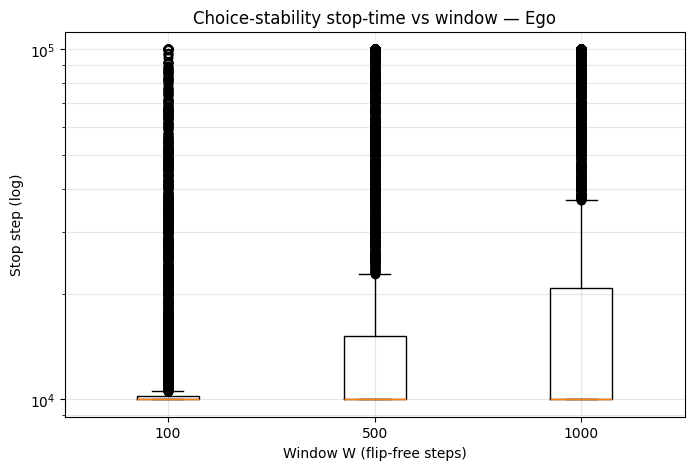

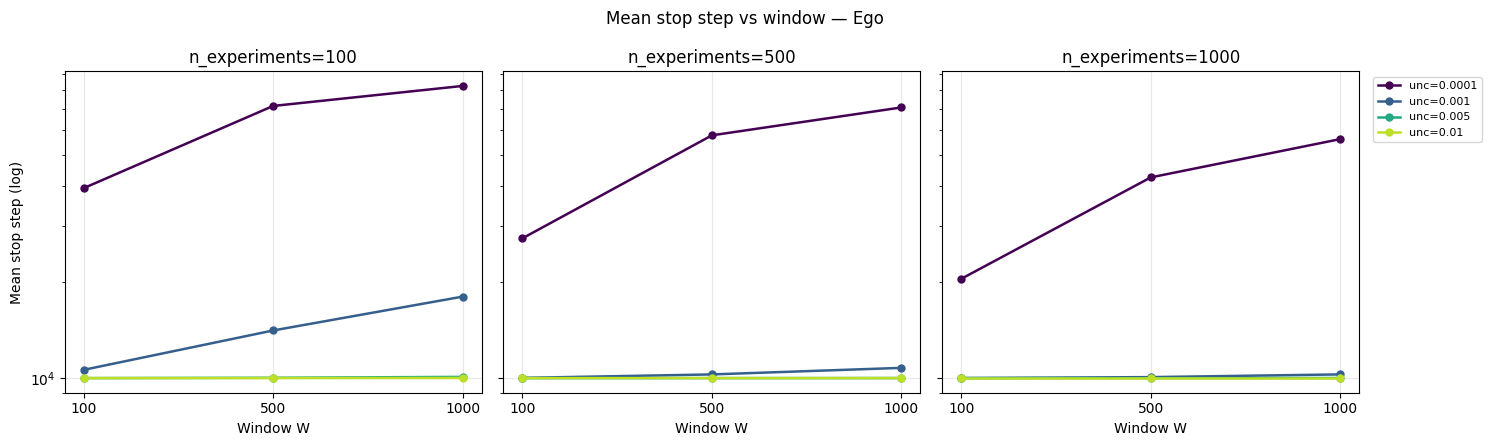

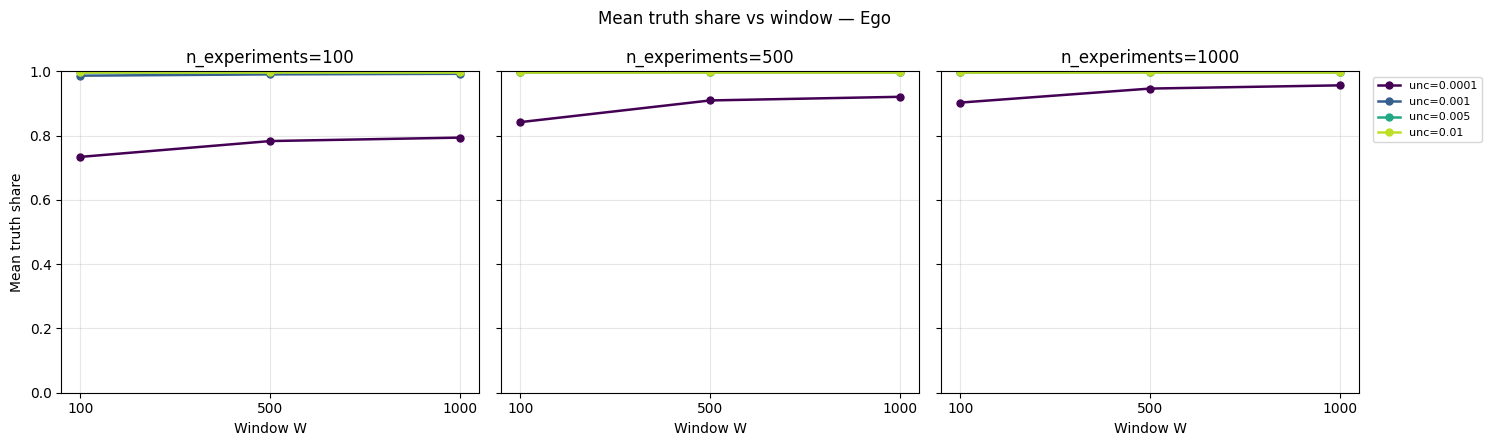

In [97]:
print("=== Choice-Stability Grid: Ego Network ===")
df_ego = run_choice_stability_grid(G_ego, "Ego", "ego")

# Study 2: Runtime & Step-Count Cost

**The adoption question.** Choice-stability stopping is only worth adopting if
its compute cost is acceptable, so this section quantifies that cost directly.

Two independent cost signals, both from the Study 1 runs (no extra simulation):

1. **Step counts** — the criterion's *intrinsic* cost, machine-independent. How
   many steps does each window need, and how heavy is the right tail (the runs
   that dominate a wall-clock budget)?
2. **Measured throughput** — steps/second actually achieved on this machine at
   `num_cores` cores, from the per-combo wall-clock in the cost CSV.

Multiplying the two projects a wall-clock budget for a full-scale study. Note the
projection is **machine-specific**: it assumes the same core count recorded in
the cost table, and assumes per-step cost is independent of the stop rule (true
here — the criterion only decides *when to break*, never what a step does).

In [98]:
# ── Study 2 — Config + load the Study 1 cost/result tables ──────────────────
# Projection knobs, defined here because the cells below both use them.
PROJ_N_RUNS       = 250    # target replicates per combo in the full-scale study
PROJ_CORES_FACTOR = 1.0    # 1.0 = same machine/core count as the measured runs
                           # (e.g. 0.5 to model twice the cores)

def load_grid_tables():
    """Concatenate the per-network Study 1 CSVs, tagging each with its network."""
    res, cost = [], []
    for label, prefix, _, _ in NETWORKS:
        rp = RESULTS_DIR / f"{prefix}_choice_stability.csv"
        cp = RESULTS_DIR / f"{prefix}_choice_stability_cost.csv"
        if rp.exists():
            d = pd.read_csv(rp); d["network"] = label; res.append(d)
        else:
            print(f"  [warn] missing {rp.name} — run Study 1 for {label} first")
        if cp.exists():
            cost.append(pd.read_csv(cp))
    if not res:
        raise FileNotFoundError("No Study 1 results found — run Study 1 first.")
    return (pd.concat(res, ignore_index=True),
            pd.concat(cost, ignore_index=True) if cost else pd.DataFrame())

grid_df, cost_df = load_grid_tables()
print(f"Grid rows: {len(grid_df):,}   networks: {sorted(grid_df.network.unique())}")
if not cost_df.empty:
    print("\nMeasured throughput by network (aggregate, all cores):")
    print(cost_df.groupby("network")
                 .agg(wall_min=("wall_sec", lambda s: s.sum() / 60),
                      steps=("total_native_steps", "sum"),
                      steps_per_sec=("steps_per_sec", "mean"),
                      cores=("num_cores", "max"))
                 .round(1).to_string())

Grid rows: 54,000   networks: ['Ego', 'PUD', 'Tobacco']

Measured throughput by network (aggregate, all cores):
         wall_min      steps  steps_per_sec  cores
network                                           
Ego         205.2  154154859        12494.0      8
PUD          70.6   84768001        20090.9      8
Tobacco     179.0  161802103        15061.8      8


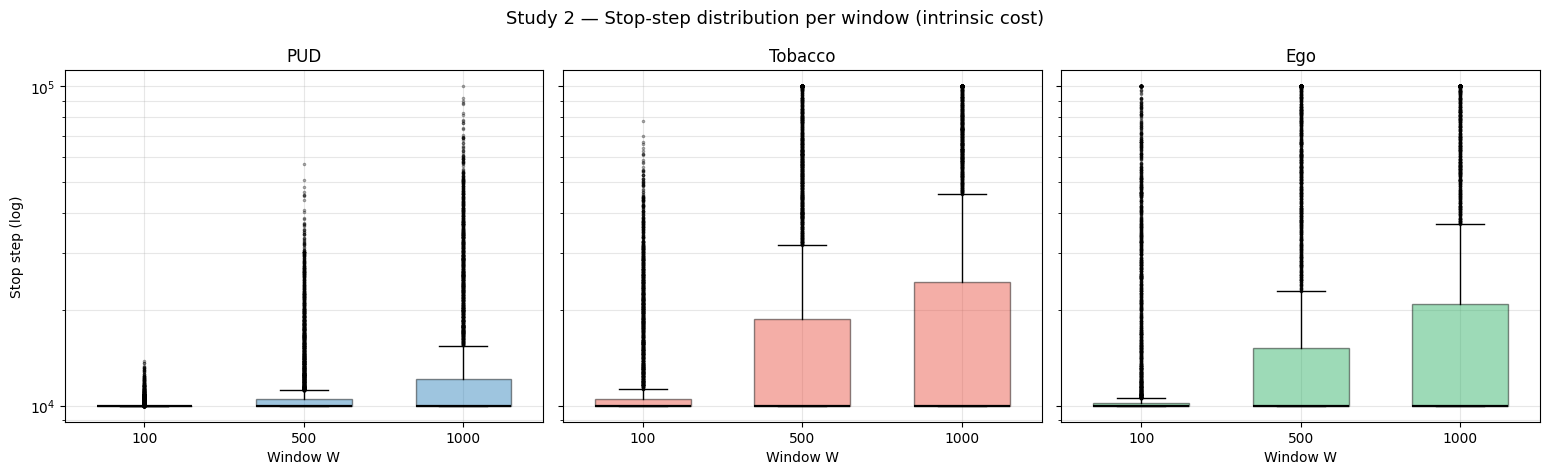


── Stop-step cost per window (steps) ──
network  window  mean  median   p90    p99    max  tail_ratio_p99_over_median
    Ego     100 14828   10000 25428  91831 100000                        9.18
    Ego     500 22173   10000 66579 100000 100000                       10.00
    Ego    1000 25690   10000 95962 100000 100000                       10.00
    PUD     100 10096   10000 10253  11746  13840                        1.17
    PUD     500 11585   10000 15758  29796  57115                        2.98
    PUD    1000 14126   10000 25954  52917 100000                        5.29
Tobacco     100 12845   10000 21248  44036  77595                        4.40
Tobacco     500 22712   10000 62759 100000 100000                       10.00
Tobacco    1000 26955   10000 91863 100000 100000                       10.00
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/study2_step_cost_table.csv (9 rows)

── Floor vs criterion (frac_at_floor = 

In [99]:
# ── (1) Step-count cost: distribution + tail per window ─────────────────────
# Stop-step distribution is the intrinsic (machine-free) cost of each window.
fig, axes = plt.subplots(1, len(NETWORKS), sharey=True,
                         figsize=(5.2 * len(NETWORKS), 4.8))
axes = np.atleast_1d(axes)
for ax, (label, _, _, color) in zip(axes, NETWORKS):
    sub = grid_df[grid_df.network == label]
    if sub.empty:
        ax.set_visible(False); continue
    data = [sub[sub.window == W]["steps"].values for W in CS_WINDOWS]
    bp = ax.boxplot(data, positions=range(len(CS_WINDOWS)), widths=0.6,
                    patch_artist=True, showfliers=True,
                    flierprops=dict(marker='.', markersize=3, alpha=0.4))
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.45)
    for med in bp['medians']:
        med.set_color('black'); med.set_linewidth(1.6)
    ax.set_xticks(range(len(CS_WINDOWS)))
    ax.set_xticklabels([str(W) for W in CS_WINDOWS])
    ax.set_yscale('log'); ax.set_xlabel("Window W")
    ax.set_title(label); ax.grid(True, alpha=0.3, which='both')
    if ax is axes[0]:
        ax.set_ylabel("Stop step (log)")
fig.suptitle("Study 2 — Stop-step distribution per window (intrinsic cost)",
             fontsize=13)
plt.tight_layout()
save_fig("study2_stop_step_distribution.png")

# Tail table: the mean is a poor budget estimate when the tail is heavy, so
# report the quantiles a budget actually has to cover.
tail = (grid_df.groupby(["network", "window"])["steps"]
        .agg(mean="mean", median="median",
             p90=lambda s: s.quantile(0.90),
             p99=lambda s: s.quantile(0.99), max="max")
        .round(0).astype(int).reset_index())
tail["tail_ratio_p99_over_median"] = (tail["p99"] / tail["median"]).round(2)
print("\n── Stop-step cost per window (steps) ──")
print(tail.to_string(index=False))
save_csv(tail, "study2_step_cost_table.csv")

# Non-stabilization rate: runs that hit CS_MAX_STEPS never satisfied the
# criterion, so they cost the full budget AND yield no stop — the worst case.
nostab = (grid_df.groupby(["network", "window"])["stabilized"]
          .agg(stabilized_rate="mean", n="size").reset_index())
nostab["hit_max_steps_rate"] = (1 - nostab["stabilized_rate"]).round(3)
# How much of the stop time is the FLOOR rather than the criterion? When the
# median sits on CS_MIN_STEPS the floor is setting the stop for most runs, and
# the window effect in `steps` is suppressed — compare against steps_nofloor.
floor_cmp = (grid_df.groupby(["network", "window"])
             .agg(mean_floored=("steps", "mean"),
                  mean_natural=("steps_nofloor", "mean"),
                  median_natural=("steps_nofloor", "median"),
                  frac_at_floor=("steps_nofloor",
                                 lambda s: float((s < CS_MIN_STEPS).mean())))
             .round(1).reset_index())
print("\n── Floor vs criterion (frac_at_floor = runs the floor held back) ──")
print(floor_cmp.to_string(index=False))
save_csv(floor_cmp, "study2_floor_vs_criterion.csv")

print("\n── Non-stabilization rate (runs that exhausted CS_MAX_STEPS) ──")
print(nostab.to_string(index=False))

── Measured aggregate throughput (steps/s, all cores) ──
network  n_experiments  steps_per_sec  cores
    Ego            100        12274.2      8
    Ego            500        12540.5      8
    Ego           1000        12667.3      8
    PUD            100        19744.8      8
    PUD            500        20137.5      8
    PUD           1000        20390.4      8
Tobacco            100        14869.7      8
Tobacco            500        15125.3      8
Tobacco           1000        15190.4      8


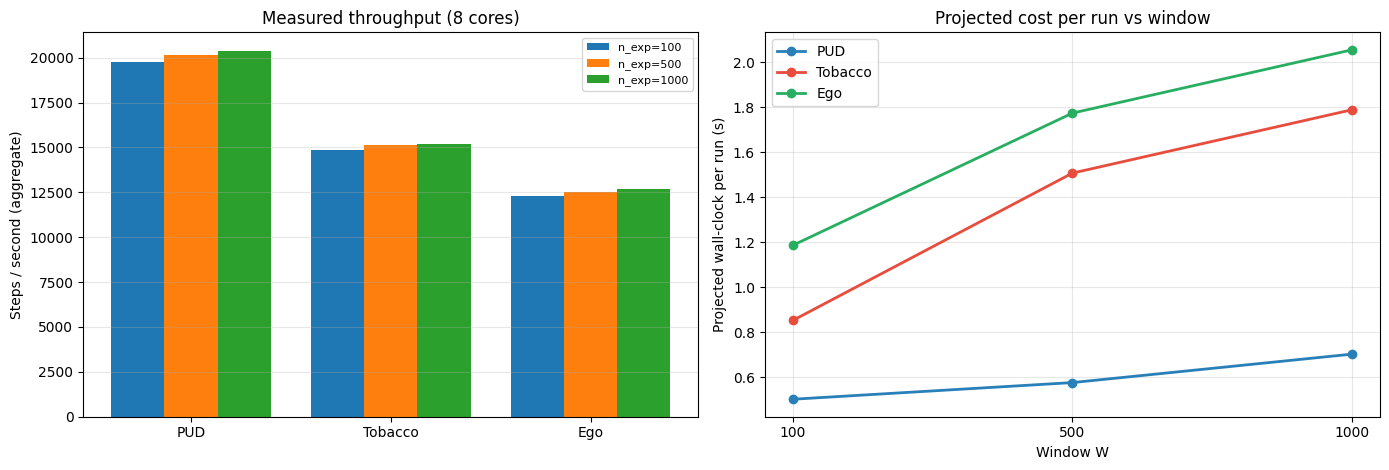

In [100]:
# ── (2) Measured throughput → projected wall-clock budget ───────────────────
# Throughput is measured at the LARGEST window (the native stop); per-step cost
# does not depend on the stop rule, so the same rate projects every window.
if cost_df.empty:
    print("No cost table — re-run Study 1 to capture wall-clock timings.")
else:
    thr = (cost_df.groupby(["network", "n_experiments"])
                  .agg(steps_per_sec=("steps_per_sec", "mean"),
                       cores=("num_cores", "max")).reset_index())
    print("── Measured aggregate throughput (steps/s, all cores) ──")
    print(thr.round(1).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    # Left: throughput per network x n_experiments (what the machine delivers).
    ax = axes[0]
    width = 0.8 / max(len(CS_N_EXPERIMENTS), 1)
    xs = np.arange(len(NETWORKS))
    for k, n_exp in enumerate(CS_N_EXPERIMENTS):
        vals = [thr[(thr.network == lbl) & (thr.n_experiments == n_exp)]
                ["steps_per_sec"].mean() for lbl, _, _, _ in NETWORKS]
        ax.bar(xs + k * width, vals, width, label=f"n_exp={n_exp}")
    ax.set_xticks(xs + width * (len(CS_N_EXPERIMENTS) - 1) / 2)
    ax.set_xticklabels([lbl for lbl, _, _, _ in NETWORKS])
    ax.set_ylabel("Steps / second (aggregate)")
    ax.set_title(f"Measured throughput ({int(thr['cores'].max())} cores)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

    # Right: projected seconds PER RUN for each window = mean stop steps / rate.
    ax = axes[1]
    for label, _, _, color in NETWORKS:
        sub = grid_df[grid_df.network == label]
        rate = thr[thr.network == label]["steps_per_sec"].mean()
        if sub.empty or not np.isfinite(rate):
            continue
        secs = [sub[sub.window == W]["steps"].mean() / rate * PROJ_CORES_FACTOR
                for W in CS_WINDOWS]
        ax.plot([str(W) for W in CS_WINDOWS], secs, 'o-', color=color,
                label=label, linewidth=2)
    ax.set_xlabel("Window W"); ax.set_ylabel("Projected wall-clock per run (s)")
    ax.set_title("Projected cost per run vs window")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig("study2_throughput_and_projection.png")

── Projected full-study wall-clock (250 runs × 12 combos, 8 cores) ──
network  window  mean_steps  runs  proj_hours
    PUD     100       10096  3000        0.42
    PUD     500       11585  3000        0.48
    PUD    1000       14126  3000        0.59
Tobacco     100       12845  3000        0.71
Tobacco     500       22712  3000        1.26
Tobacco    1000       26955  3000        1.49
    Ego     100       14828  3000        0.99
    Ego     500       22173  3000        1.48
    Ego    1000       25690  3000        1.71

NOTE: the record-once design means the ACTUAL cost is the largest window only (W=1000); smaller windows are derived offline for free. The per-window rows show what a naive run-each-window-natively design would have cost.
  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/study2_runtime_projection.csv (9 rows)

>>> Record-once total across networks: 3.79 h (vs 9.13 h run-each-window)


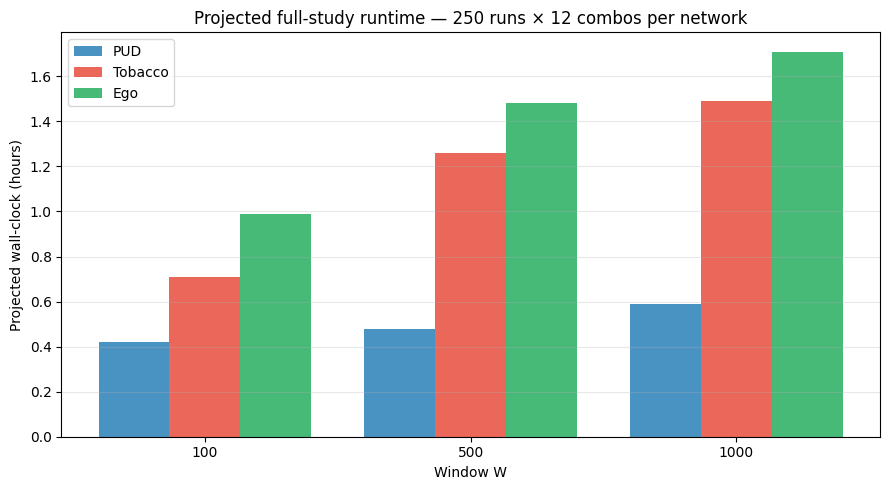

In [101]:
# ── (3) Full-scale budget projection ────────────────────────────────────────
# "If I run PROJ_N_RUNS seeds per combo at window W, how long does it take?"
# (PROJ_N_RUNS / PROJ_CORES_FACTOR are set in the Study 2 config cell above.)
if cost_df.empty:
    print("No cost table — re-run Study 1 to capture wall-clock timings.")
else:
    n_combos = len(CS_N_EXPERIMENTS) * len(CS_UNCERTAINTIES)
    proj = []
    for label, _, _, _ in NETWORKS:
        sub = grid_df[grid_df.network == label]
        rate = cost_df[cost_df.network == label]["steps_per_sec"].mean()
        if sub.empty or not np.isfinite(rate):
            continue
        for W in CS_WINDOWS:
            mean_steps = sub[sub.window == W]["steps"].mean()
            total_steps = mean_steps * PROJ_N_RUNS * n_combos
            secs = total_steps / rate * PROJ_CORES_FACTOR
            proj.append({"network": label, "window": W,
                         "mean_steps": round(mean_steps),
                         "runs": PROJ_N_RUNS * n_combos,
                         "proj_hours": round(secs / 3600, 2)})
    proj_df = pd.DataFrame(proj)
    print(f"── Projected full-study wall-clock "
          f"({PROJ_N_RUNS} runs \u00d7 {n_combos} combos, "
          f"{int(cost_df['num_cores'].max())} cores) ──")
    print(proj_df.to_string(index=False))
    print(f"\nNOTE: the record-once design means the ACTUAL cost is the largest "
          f"window only (W={max(CS_WINDOWS)}); smaller windows are derived "
          f"offline for free. The per-window rows show what a naive "
          f"run-each-window-natively design would have cost.")
    save_csv(proj_df, "study2_runtime_projection.csv")

    actual = proj_df[proj_df.window == max(CS_WINDOWS)]
    print(f"\n>>> Record-once total across networks: "
          f"{actual['proj_hours'].sum():.2f} h "
          f"(vs {proj_df['proj_hours'].sum():.2f} h run-each-window)")

    plt.figure(figsize=(9, 5))
    xs = np.arange(len(CS_WINDOWS))
    width = 0.8 / max(len(NETWORKS), 1)
    for k, (label, _, _, color) in enumerate(NETWORKS):
        sub = proj_df[proj_df.network == label]
        if sub.empty:
            continue
        vals = [sub[sub.window == W]["proj_hours"].sum() for W in CS_WINDOWS]
        plt.bar(xs + k * width, vals, width, label=label, color=color, alpha=0.85)
    plt.xticks(xs + width * (len(NETWORKS) - 1) / 2, [str(W) for W in CS_WINDOWS])
    plt.xlabel("Window W"); plt.ylabel("Projected wall-clock (hours)")
    plt.title(f"Projected full-study runtime — {PROJ_N_RUNS} runs \u00d7 "
              f"{n_combos} combos per network")
    plt.legend(); plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_fig("study2_runtime_budget.png")

# Study 3: Belief-Dynamics Trajectories

Mean **truth share** and **max absolute belief change** vs step, mirroring
`A_100k_Stopping_Study.ipynb` — but under *choice-stability* stopping rather
than a fixed step count. This shows what the system looks like at the moment the
criterion fires: truth share should have plateaued and max |Δcredence| should have
decayed by orders of magnitude.

**Ragged trajectories.** Unlike the fixed-step 100k study, runs here stop at
*different* steps, so the per-run snapshot arrays have different lengths. They
are NaN-padded and aggregated with `nanmean`/`nanstd`; the shaded **survivor
count** panel shows how many runs are still active at each step, so the
right-hand tail of the curves (few survivors) is read with appropriate caution.

In [102]:
# ── Study 3 — Config ────────────────────────────────────────────────────────
# A single representative parameter point (matching the Study 5 comparison
# point), snapshotted every SNAPSHOT_INTERVAL steps under native choice-stability
# stopping at the largest window.
TRAJ_UNCERTAINTY   = 0.001
TRAJ_N_EXPERIMENTS = 500 if not SMOKE_TEST else 100
TRAJ_N_RUNS        = 5 if SMOKE_TEST else (30 if RUNNING_LOCALLY else 100)
TRAJ_WINDOW        = max(CS_WINDOWS)
print(f"unc={TRAJ_UNCERTAINTY} n_exp={TRAJ_N_EXPERIMENTS} runs={TRAJ_N_RUNS} "
      f"W={TRAJ_WINDOW} snapshot_interval={SNAPSHOT_INTERVAL}")

unc=0.001 n_exp=500 runs=100 W=1000 snapshot_interval=500


In [103]:
def aggregate_snapshots_ragged(all_snapshots):
    """Aggregate variable-length snapshot trajectories.

    Runs under choice-stability stopping end at different steps, so each run's
    snapshot list has its own length. Pad every run to the longest with NaN and
    aggregate with nanmean/nanstd, also returning how many runs are still alive
    at each step (n_alive) — the honest denominator for the right-hand tail.

    Returns (steps, mean_truth, std_truth, mean_change, std_change, n_alive).
    """
    longest = max(all_snapshots, key=lambda s: len(s['step']))
    steps = np.asarray(longest['step'], dtype=float)
    L = len(steps)

    def pad(key):
        out = np.full((len(all_snapshots), L), np.nan)
        for i, s in enumerate(all_snapshots):
            v = np.array([np.nan if x is None else x for x in s[key]], dtype=float)
            out[i, :len(v)] = v[:L]
        return out

    truth  = pad('truth_share')
    change = pad('max_belief_change')
    n_alive = np.sum(~np.isnan(truth), axis=0)  # runs contributing at each step

    with np.errstate(invalid='ignore'):
        mean_truth  = np.nanmean(truth, axis=0)
        std_truth   = np.nanstd(truth, axis=0)
        # A bayes run yields None for max_belief_change → all-NaN column.
        mean_change = (np.nanmean(change, axis=0)
                       if not np.all(np.isnan(change)) else None)
        std_change  = (np.nanstd(change, axis=0)
                       if mean_change is not None else None)
    return steps, mean_truth, std_truth, mean_change, std_change, n_alive

In [104]:
def run_trajectory_study(network, network_label, output_prefix,
                         master_seed=MASTER_SEED):
    """Run TRAJ_N_RUNS snapshotted seeds under native choice-stability stopping."""
    seeds = [int(s.generate_state(1)[0])
             for s in SeedSequence(master_seed + 2).spawn(TRAJ_N_RUNS)]
    param_dicts = [{"network": network, "n_experiments": TRAJ_N_EXPERIMENTS,
                    "uncertainty": TRAJ_UNCERTAINTY, "seed": s} for s in seeds]
    wrapper = partial(
        run_vectorized_simulation_with_params,
        tolerance_stopping=False,
        choice_stability_stopping=True,
        choice_stability_window=TRAJ_WINDOW,
        choice_stability_min_steps=CS_MIN_STEPS,
        number_of_steps=CS_MAX_STEPS,
        snapshot_interval=SNAPSHOT_INTERVAL,
        show_bar=False, agent_type="beta",
    )
    t0 = time.time()
    with Pool(num_cores) as pool:
        results = list(tqdm(pool.imap_unordered(wrapper, param_dicts),
                            total=TRAJ_N_RUNS, desc=f"[{network_label}] traj"))
    stops = [r["convergence_step"] for r in results]
    print(f"  [{network_label}] {TRAJ_N_RUNS} runs in {time.time()-t0:.1f}s | "
          f"stop step mean={np.mean(stops):.0f} median={np.median(stops):.0f} "
          f"max={max(stops)}")
    snaps = [r["snapshots"] for r in results if r.get("snapshots")]
    if not snaps:
        print(f"  [{network_label}] no snapshots recorded — is SNAPSHOT_INTERVAL "
              f"larger than the stop step?")
    return snaps, stops


def plot_trajectories(snaps, stops, network_label, output_prefix, color):
    if not snaps:
        print(f"[{network_label}] nothing to plot."); return
    steps, mt, st, mc, sc, n_alive = aggregate_snapshots_ragged(snaps)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8),
                             gridspec_kw={'width_ratios': [1, 1, 0.7]})
    fig.suptitle(f"{network_label} — trajectories under choice-stability "
                 f"stopping (W={TRAJ_WINDOW}, n={len(snaps)} runs)", fontsize=13)

    # Left: mean truth share ±1 SD.
    ax = axes[0]
    ax.plot(steps, mt, color=color, linewidth=2, label='Mean')
    ax.fill_between(steps, mt - st, mt + st, alpha=0.25, color=color, label='±1 SD')
    ax.axvline(np.median(stops), color='k', ls='--', lw=1.2,
               label=f'Median stop ({np.median(stops):.0f})')
    ax.set_xlabel('Step'); ax.set_ylabel('Truth share')
    ax.set_title('Mean Truth Share'); ax.set_ylim(0, 1)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

    # Middle: max |Δcredence| on a log scale — the stabilization proxy.
    ax = axes[1]
    if mc is not None:
        ax.plot(steps, mc, color=color, linewidth=2, label='Mean')
        ax.fill_between(steps, np.maximum(mc - sc, 1e-12), mc + sc,
                        alpha=0.25, color=color, label='±1 SD')
        ax.set_yscale('log')
        ax.axvline(np.median(stops), color='k', ls='--', lw=1.2,
                   label='Median stop')
        ax.set_xlabel('Step'); ax.set_ylabel('Max |Δcredence|')
        ax.set_title('Max Absolute Belief Change')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.4, which='both')
    else:
        ax.set_visible(False)

    # Right: survivor count — how many runs still contribute at each step.
    ax = axes[2]
    ax.plot(steps, n_alive, color='dimgray', linewidth=2)
    ax.fill_between(steps, 0, n_alive, alpha=0.2, color='dimgray')
    ax.set_xlabel('Step'); ax.set_ylabel('Runs still active')
    ax.set_title('Survivors (trust the curves\nonly while this is high)')
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    save_fig(f"{output_prefix}_choice_stability_trajectories.png")

=== Trajectory Study: PUD Network ===


[PUD] traj:   0%|          | 0/100 [00:00<?, ?it/s]

  [PUD] 100 runs in 50.2s | stop step mean=10033 median=10000 max=10576


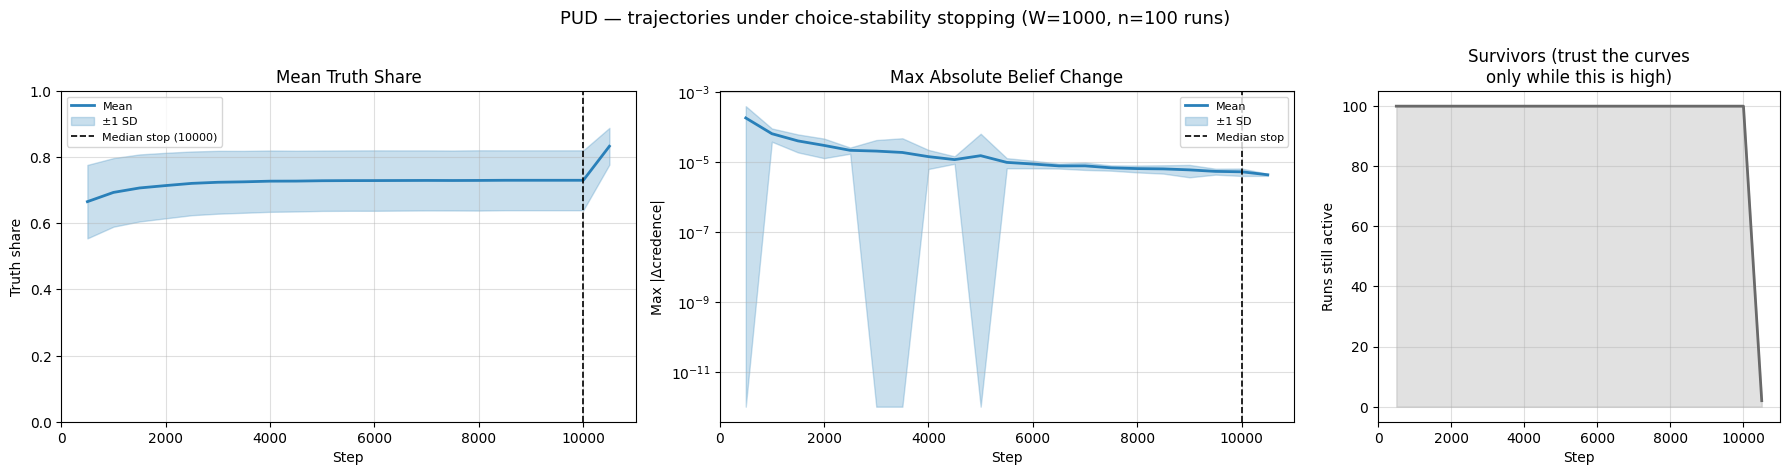

=== Trajectory Study: Tobacco Network ===


[Tobacco] traj:   0%|          | 0/100 [00:00<?, ?it/s]

  [Tobacco] 100 runs in 72.3s | stop step mean=10411 median=10000 max=14732


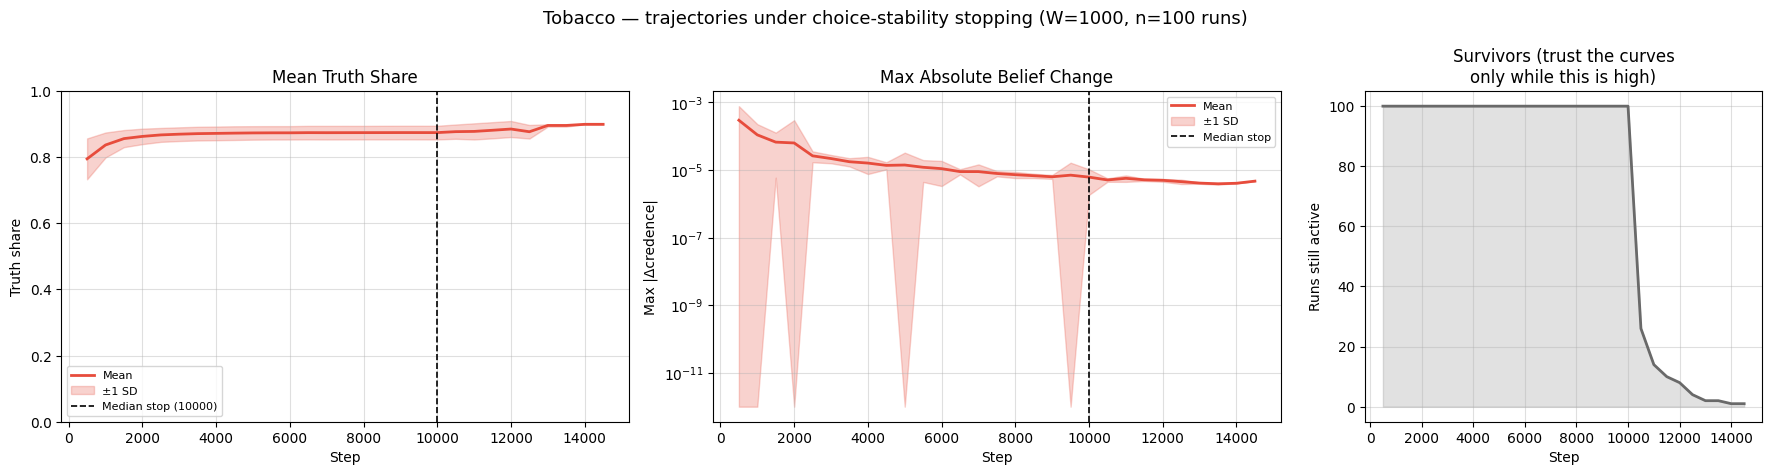

=== Trajectory Study: Ego Network ===


[Ego] traj:   0%|          | 0/100 [00:00<?, ?it/s]

  [Ego] 100 runs in 91.3s | stop step mean=11032 median=10000 max=21092


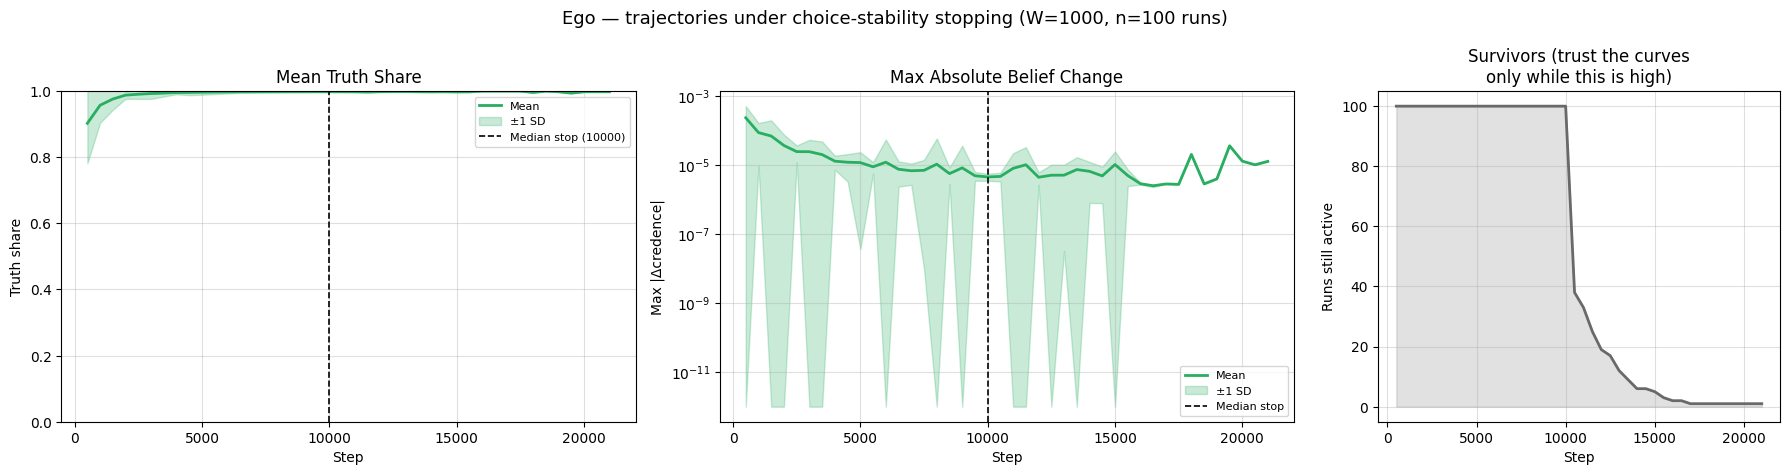

In [105]:
# ── Run the trajectory study on all three networks ──────────────────────────
traj_results = {}
for label, prefix, G, color in NETWORKS:
    print(f"=== Trajectory Study: {label} Network ===")
    snaps, stops = run_trajectory_study(G, label, prefix)
    traj_results[label] = (snaps, stops, color, prefix)
    plot_trajectories(snaps, stops, label, prefix, color)

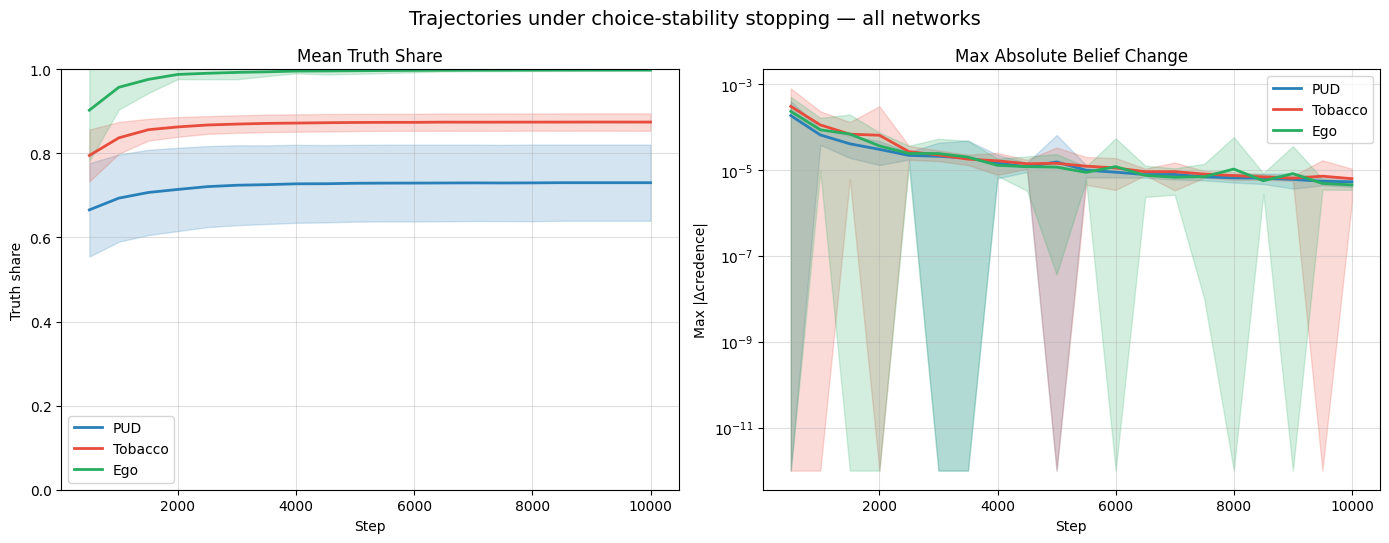

(curves truncated where fewer than half the runs remain active)


In [106]:
# ── Combined comparison across networks ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Trajectories under choice-stability stopping — all networks',
             fontsize=14)
for label, (snaps, stops, color, _) in traj_results.items():
    if not snaps:
        continue
    steps, mt, st, mc, sc, n_alive = aggregate_snapshots_ragged(snaps)
    # Only plot while a majority of runs are still active, so the tail is not
    # dominated by one or two stragglers.
    keep = n_alive >= max(1, 0.5 * len(snaps))
    axes[0].plot(steps[keep], mt[keep], color=color, linewidth=2, label=label)
    axes[0].fill_between(steps[keep], (mt - st)[keep], (mt + st)[keep],
                         alpha=0.2, color=color)
    if mc is not None:
        axes[1].plot(steps[keep], mc[keep], color=color, linewidth=2, label=label)
        axes[1].fill_between(steps[keep], np.maximum((mc - sc)[keep], 1e-12),
                             (mc + sc)[keep], alpha=0.2, color=color)

axes[0].set_title('Mean Truth Share'); axes[0].set_xlabel('Step')
axes[0].set_ylabel('Truth share'); axes[0].set_ylim(0, 1)
axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[1].set_title('Max Absolute Belief Change'); axes[1].set_xlabel('Step')
axes[1].set_ylabel('Max |Δcredence|'); axes[1].set_yscale('log')
axes[1].legend(); axes[1].grid(True, alpha=0.4, which='both')
plt.tight_layout()
save_fig("all_networks_choice_stability_trajectories.png")
print("(curves truncated where fewer than half the runs remain active)")

# Study 4: Data Analysis — H1′ / H2′

Log₁₀-transformed predictors `log_window`, `log_uncertainty`,
`log_n_experiments`. **H1′:** steps driven by window (+ uncertainty,
n_experiments). **H2′:** truth share driven by uncertainty and ~invariant to
window (its standardized coefficient / Cohen's f² for `log_window` should be
near zero). Run per network across all three networks.

In [107]:
from utils.data_analysis_utils import (
    compute_correlations, compute_vif,
    run_ols, regression_diagnostics, plot_f2_comparison,
)

In [108]:
def analyze_choice_stability(network_label, output_prefix):
    df = pd.read_csv(RESULTS_DIR / f"{output_prefix}_choice_stability.csv")
    df['log_window']        = np.log10(df['window'])
    df['log_uncertainty']   = np.log10(df['uncertainty'])
    df['log_n_experiments'] = np.log10(df['n_experiments'])
    predictors = ['log_window', 'log_uncertainty', 'log_n_experiments']

    print(f"\n{'='*60}\n  Choice-Stability Analysis: {network_label}  "
          f"(n={len(df)})\n{'='*60}\n")

    print("── Multicollinearity: Pearson correlations ──")
    compute_correlations(df, predictors)
    print("\n── Multicollinearity: Variance Inflation Factors ──")
    display(compute_vif(df, predictors))

    print("\n── Regression: Steps to Stabilization  (H1′) ──")
    model_steps = run_ols(df, predictors, dependent='steps',
                          label='Steps to Stabilization',
                          network_label=network_label)
    regression_diagnostics(model_steps,
                           title=f"Diagnostics: Steps — {network_label}")

    # H1' on the UNFLOORED series: with CS_MIN_STEPS binding for most runs the
    # floored `steps` regression understates the window effect, so the criterion's
    # own behaviour is tested here and the two are reported side by side.
    model_steps_nf = None
    if 'steps_nofloor' in df.columns:
        print("\n── Regression: Steps, floor removed  (H1′, criterion only) ──")
        model_steps_nf = run_ols(df, predictors, dependent='steps_nofloor',
                                 label='Steps (no floor)',
                                 network_label=network_label)

    print("\n── Regression: Truth Share at Stabilization  (H2′) ──")
    model_truth = run_ols(df, predictors, dependent='truth_share',
                          label='Truth Share', network_label=network_label)
    regression_diagnostics(model_truth,
                           title=f"Diagnostics: Truth Share — {network_label}")

    plot_f2_comparison(
        models={'Steps to Stabilization': model_steps,
                **({'Steps (no floor)': model_steps_nf} if model_steps_nf else {}),
                'Truth Share': model_truth},
        predictors=predictors,
        title=f"Cohen's f² — {network_label} (expect log_window ~0 for Truth Share)")

## PUD Network

=== Choice-Stability Data Analysis: PUD Network ===

  Choice-Stability Analysis: PUD  (n=18000)

── Multicollinearity: Pearson correlations ──


,log_window,log_uncertainty,log_n_experiments
log_window,1.0,0.0,0.0
log_uncertainty,0.0,1.0,-0.0
log_n_experiments,0.0,-0.0,1.0


,log_window,log_uncertainty,log_n_experiments
log_window,strong,weak,weak
log_uncertainty,weak,strong,weak
log_n_experiments,weak,weak,strong



── Multicollinearity: Variance Inflation Factors ──


,variable,VIF,VIF interpretation
0,log_window,1.0,minimal multicollinearity
1,log_uncertainty,1.0,no multicollinearity
2,log_n_experiments,1.0,something went wrong



── Regression: Steps to Stabilization  (H1′) ──
OLS: Steps to Stabilization — PUD
R² = 0.2788    Adj. R² = 0.2786    n = 18000
------------------------------------------------------------
Descriptive statistics (predictors)
------------------------------------------------------------


,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,-0.4607,0.2943,Medium,0.0
log_window,0.2490,0.0860,Small,0.0
log_n_experiments,-0.0672,0.0063,Negligible,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                  steps   R-squared:                       0.279
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     2318.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:43   Log-Likelihood:            -1.7983e+05
No. Observations:               18000   AIC:                         3.597e+05
Df Residuals:                   17996   BIC:                         3.597e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

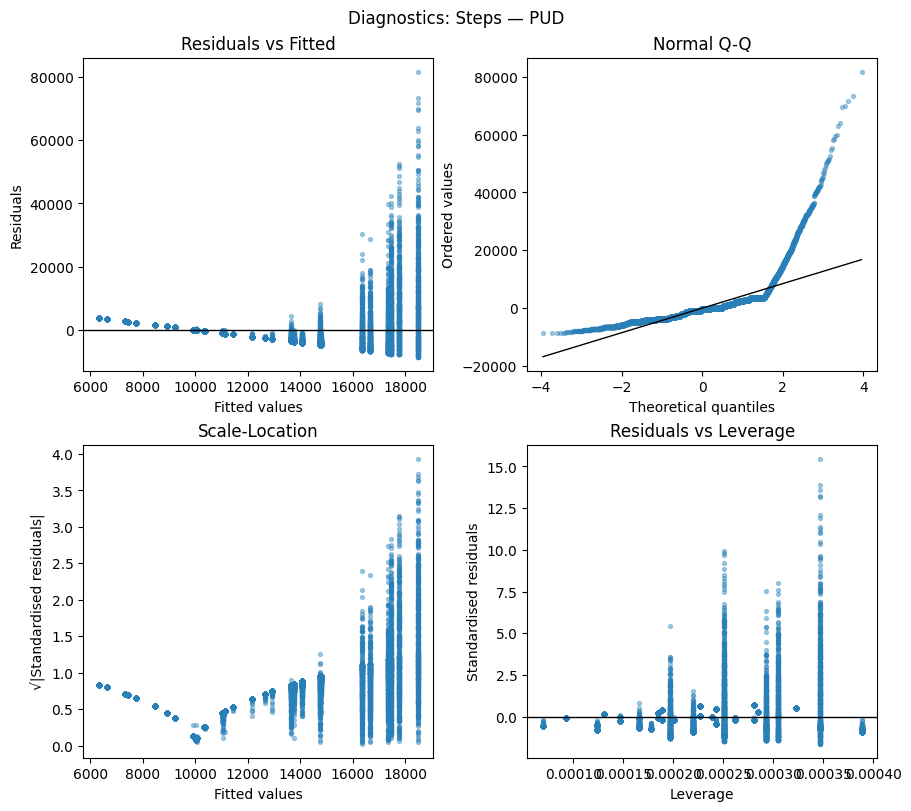


── Regression: Steps, floor removed  (H1′, criterion only) ──
OLS: Steps (no floor) — PUD
R² = 0.4804    Adj. R² = 0.4803    n = 18000
------------------------------------------------------------
Descriptive statistics (predictors)
------------------------------------------------------------


,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,-0.6018,0.6969,Large,0.0
log_window,0.3293,0.2087,Medium,0.0
log_n_experiments,-0.0987,0.0188,Negligible,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:          steps_nofloor   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     5545.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:43   Log-Likelihood:            -1.8240e+05
No. Observations:               18000   AIC:                         3.648e+05
Df Residuals:                   17996   BIC:                         3.648e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,0.6626,0.8225,Large,0.0
log_n_experiments,0.1631,0.0498,Small,0.0
log_window,0.0245,0.0011,Negligible,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:            truth_share   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     5239.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:44   Log-Likelihood:                 16223.
No. Observations:               18000   AIC:                        -3.244e+04
Df Residuals:                   17996   BIC:                        -3.241e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

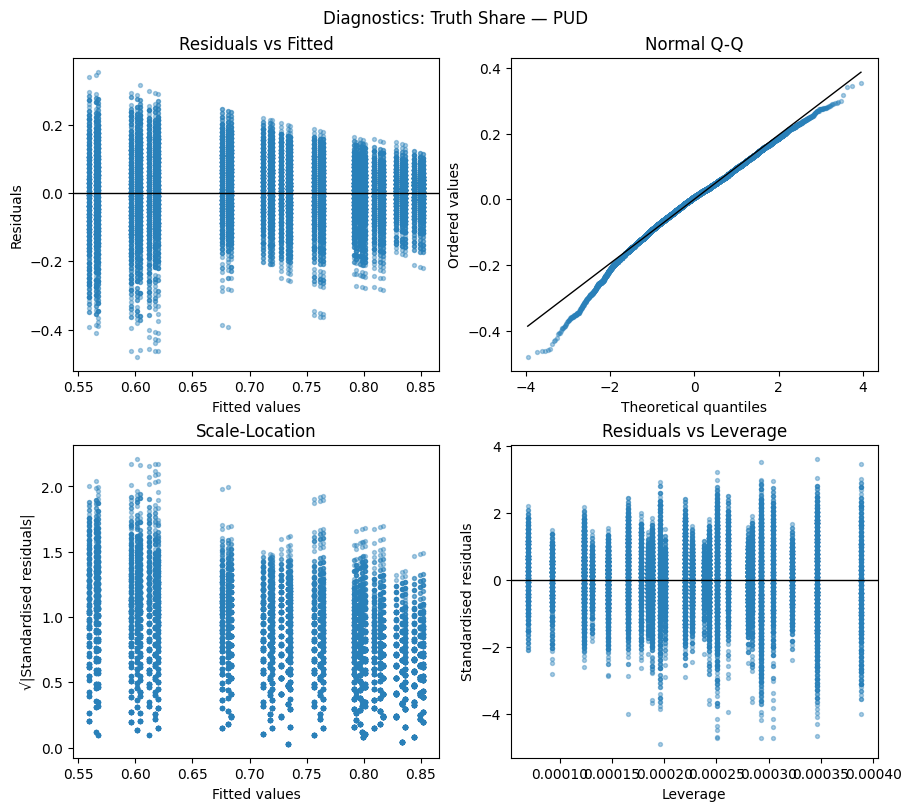

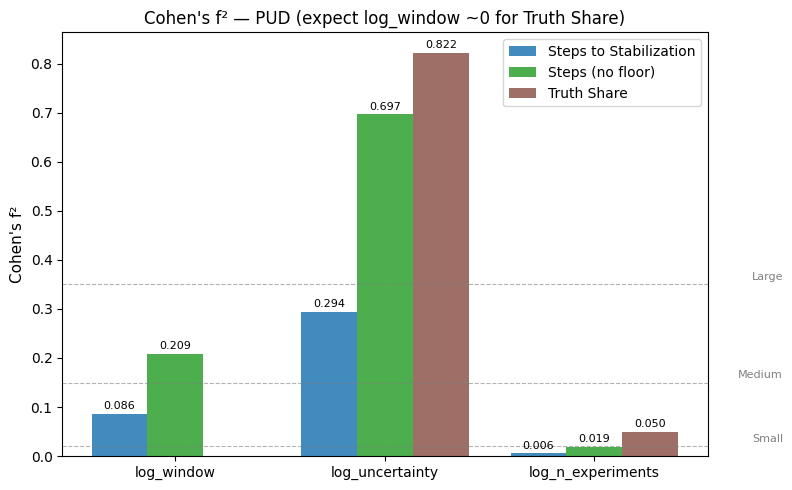

In [109]:
print("=== Choice-Stability Data Analysis: PUD Network ===")
analyze_choice_stability("PUD", "pud")

## Tobacco Network

=== Choice-Stability Data Analysis: Tobacco Network ===

  Choice-Stability Analysis: Tobacco  (n=18000)

── Multicollinearity: Pearson correlations ──


,log_window,log_uncertainty,log_n_experiments
log_window,1.0,0.0,0.0
log_uncertainty,0.0,1.0,-0.0
log_n_experiments,0.0,-0.0,1.0


,log_window,log_uncertainty,log_n_experiments
log_window,strong,weak,weak
log_uncertainty,weak,strong,weak
log_n_experiments,weak,weak,strong



── Multicollinearity: Variance Inflation Factors ──


,variable,VIF,VIF interpretation
0,log_window,1.0,minimal multicollinearity
1,log_uncertainty,1.0,no multicollinearity
2,log_n_experiments,1.0,something went wrong



── Regression: Steps to Stabilization  (H1′) ──
OLS: Steps to Stabilization — Tobacco
R² = 0.5419    Adj. R² = 0.5418    n = 18000
------------------------------------------------------------
Descriptive statistics (predictors)
------------------------------------------------------------


,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,-0.6775,1.0021,Large,0.0
log_window,0.2470,0.1332,Small,0.0
log_n_experiments,-0.1477,0.0476,Small,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                  steps   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     7096.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:45   Log-Likelihood:            -2.0001e+05
No. Observations:               18000   AIC:                         4.000e+05
Df Residuals:                   17996   BIC:                         4.001e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

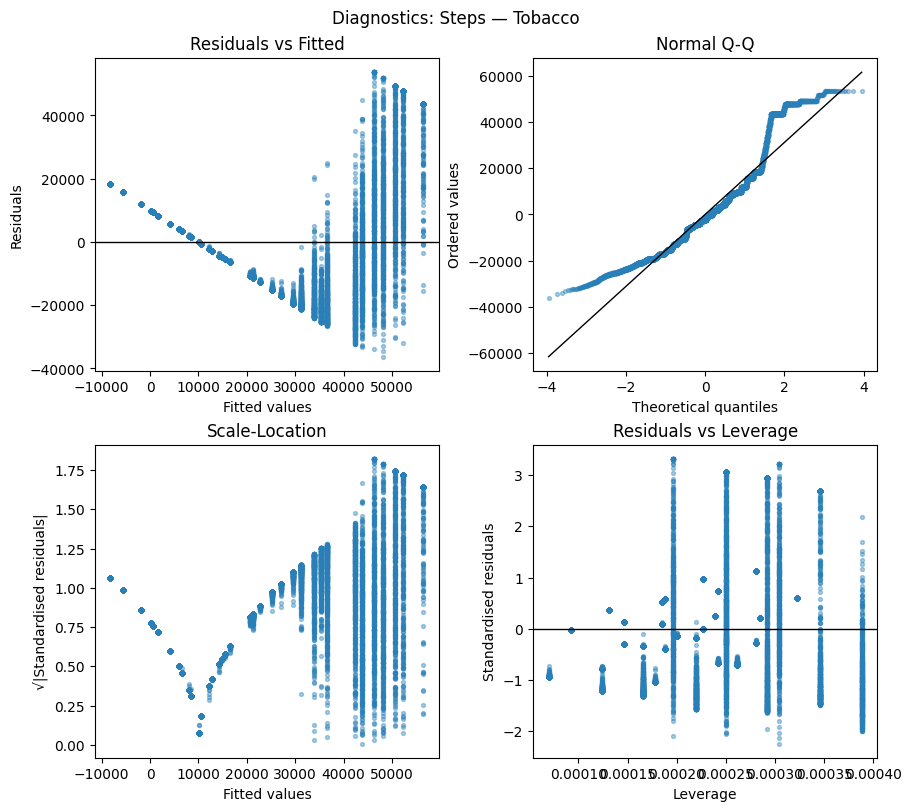


── Regression: Steps, floor removed  (H1′, criterion only) ──
OLS: Steps (no floor) — Tobacco
R² = 0.6355    Adj. R² = 0.6354    n = 18000
------------------------------------------------------------
Descriptive statistics (predictors)
------------------------------------------------------------


,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,-0.7410,1.5063,Large,0.0
log_window,0.2474,0.1679,Medium,0.0
log_n_experiments,-0.1586,0.0690,Small,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:          steps_nofloor   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.635
Method:                 Least Squares   F-statistic:                 1.046e+04
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:46   Log-Likelihood:            -1.9993e+05
No. Observations:               18000   AIC:                         3.999e+05
Df Residuals:                   17996   BIC:                         3.999e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,0.6929,1.0717,Large,0.0
log_n_experiments,0.2388,0.1273,Small,0.0
log_window,0.1220,0.0332,Small,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:            truth_share   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     7391.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:46   Log-Likelihood:                 28411.
No. Observations:               18000   AIC:                        -5.681e+04
Df Residuals:                   17996   BIC:                        -5.678e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

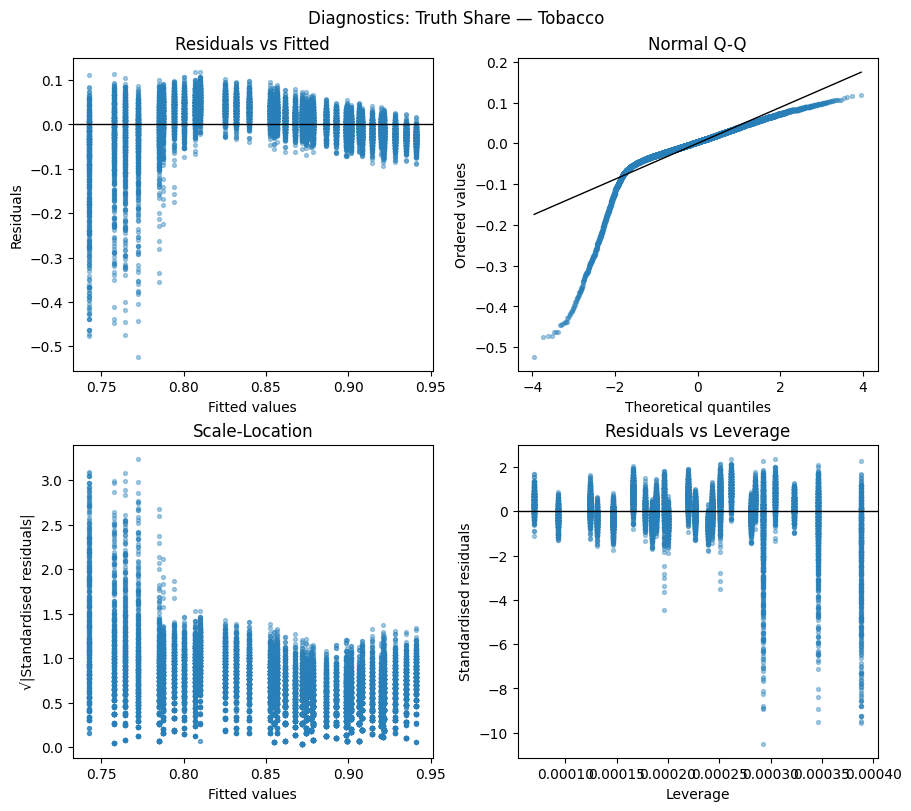

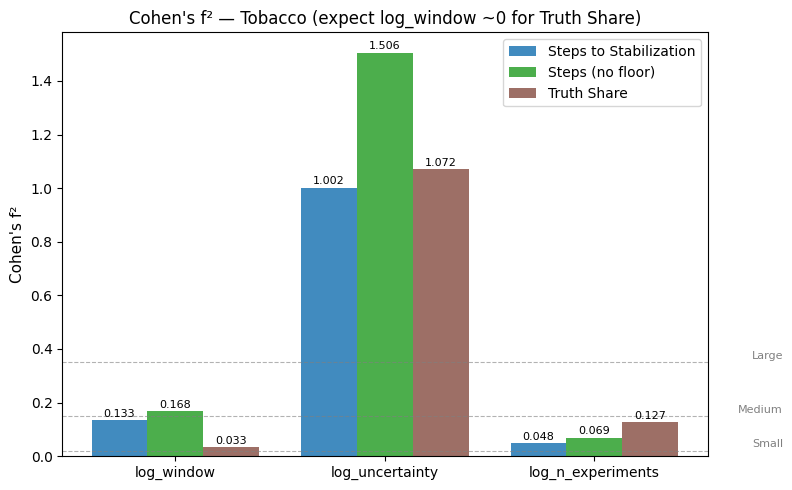

In [110]:
print("=== Choice-Stability Data Analysis: Tobacco Network ===")
analyze_choice_stability("Tobacco", "tobacco")

## Ego Network

=== Choice-Stability Data Analysis: Ego Network ===

  Choice-Stability Analysis: Ego  (n=18000)

── Multicollinearity: Pearson correlations ──


,log_window,log_uncertainty,log_n_experiments
log_window,1.0,0.0,0.0
log_uncertainty,0.0,1.0,-0.0
log_n_experiments,0.0,-0.0,1.0


,log_window,log_uncertainty,log_n_experiments
log_window,strong,weak,weak
log_uncertainty,weak,strong,weak
log_n_experiments,weak,weak,strong



── Multicollinearity: Variance Inflation Factors ──


,variable,VIF,VIF interpretation
0,log_window,1.0,minimal multicollinearity
1,log_uncertainty,1.0,no multicollinearity
2,log_n_experiments,1.0,something went wrong



── Regression: Steps to Stabilization  (H1′) ──
OLS: Steps to Stabilization — Ego
R² = 0.4721    Adj. R² = 0.4720    n = 18000
------------------------------------------------------------
Descriptive statistics (predictors)
------------------------------------------------------------


,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,-0.6517,0.8047,Large,0.0
log_window,0.1829,0.0633,Small,0.0
log_n_experiments,-0.1180,0.0264,Small,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                  steps   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     5365.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:47   Log-Likelihood:            -2.0188e+05
No. Observations:               18000   AIC:                         4.038e+05
Df Residuals:                   17996   BIC:                         4.038e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

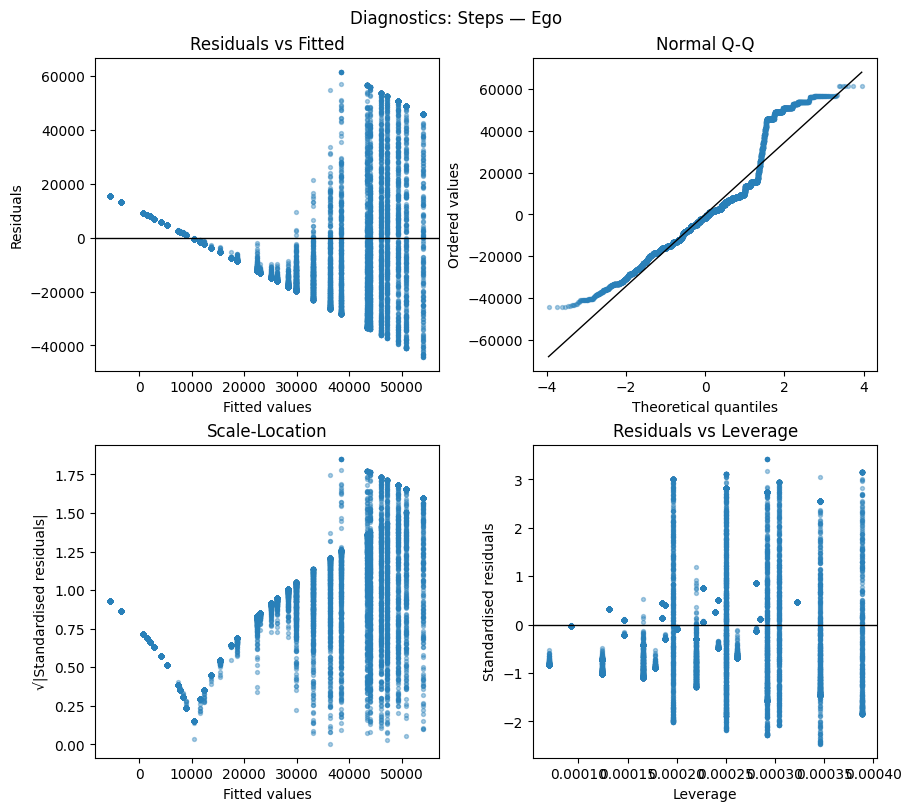


── Regression: Steps, floor removed  (H1′, criterion only) ──
OLS: Steps (no floor) — Ego
R² = 0.5555    Adj. R² = 0.5554    n = 18000
------------------------------------------------------------
Descriptive statistics (predictors)
------------------------------------------------------------


,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,-0.7064,1.1227,Large,0.0
log_window,0.1991,0.0892,Small,0.0
log_n_experiments,-0.1295,0.0377,Small,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:          steps_nofloor   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     7496.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:48   Log-Likelihood:            -2.0215e+05
No. Observations:               18000   AIC:                         4.043e+05
Df Residuals:                   17996   BIC:                         4.043e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

,Mean,Std
log_window,2.5663,0.4189
log_uncertainty,-2.8253,0.7692
log_n_experiments,2.5663,0.4189


------------------------------------------------------------
Predictor strength
------------------------------------------------------------


,Norm. Coef,f²,f² Interpretation,p-value
log_uncertainty,0.3957,0.1910,Medium,0.0
log_n_experiments,0.1427,0.0248,Small,0.0
log_window,0.0555,0.0038,Negligible,0.0


------------------------------------------------------------
Full summary
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:            truth_share   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     1317.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:40:48   Log-Likelihood:                 13111.
No. Observations:               18000   AIC:                        -2.621e+04
Df Residuals:                   17996   BIC:                        -2.618e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

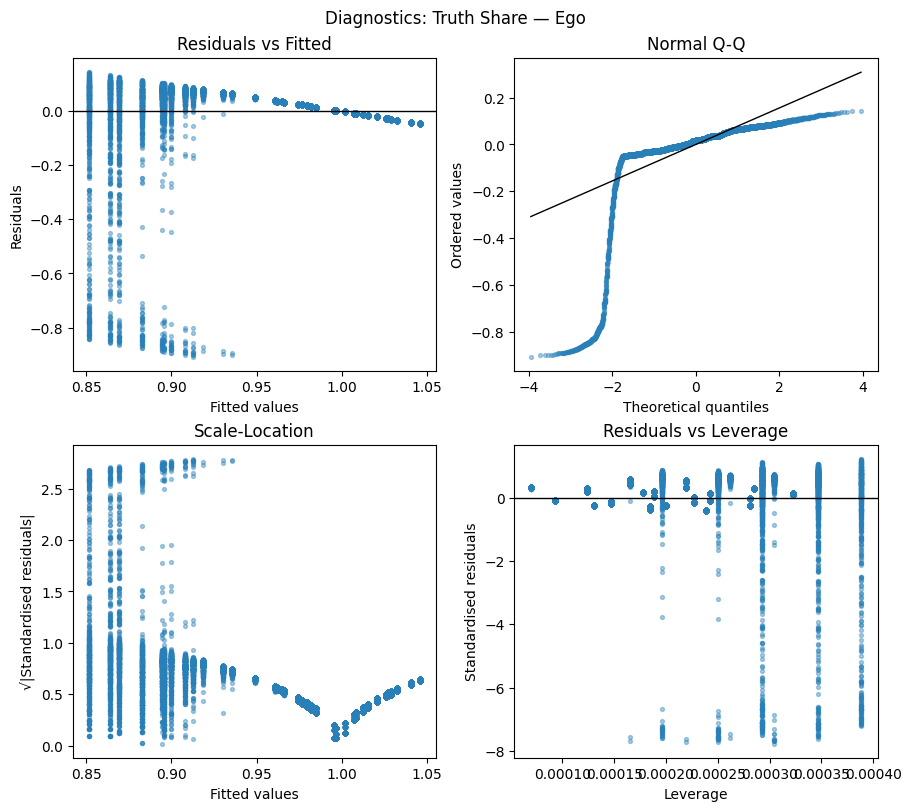

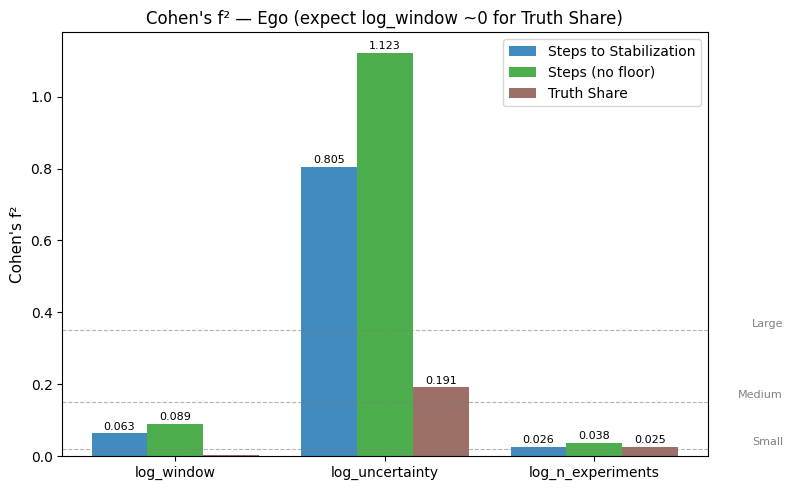

In [111]:
print("=== Choice-Stability Data Analysis: Ego Network ===")
analyze_choice_stability("Ego", "ego")

# Study 5: Comparison vs Tolerance Stopping + Post-Stop Drift

On **shared seeds**, compare tolerance stopping (default `tol=5e-3`) against
choice-stability stopping for each window `W`, at a representative parameter
point. For each stopped state we resume `K` extra steps and measure the
**post-stop flip fraction** (agents that cross the 0.5 boundary after the stop).
Hypothesis (RQ4): choice-stability yields a far lower post-stop flip rate than
tolerance stopping. Run on all three networks.

In [112]:
# ── Study 2 — Config ─────────────────────────────────────────────────────────
CMP_UNCERTAINTY   = 0.001
CMP_N_EXPERIMENTS = 500 if not SMOKE_TEST else 100
CMP_TOLERANCE     = 5e-3
CMP_N_RUNS        = 5 if SMOKE_TEST else (30 if RUNNING_LOCALLY else 100)
CMP_CONTINUATION  = 200 if SMOKE_TEST else 10_000    # K steps resumed after stop
print(f"unc={CMP_UNCERTAINTY} n_exp={CMP_N_EXPERIMENTS} tol={CMP_TOLERANCE} "
      f"runs={CMP_N_RUNS} K={CMP_CONTINUATION}")

unc=0.001 n_exp=500 tol=0.005 runs=100 K=10000


In [113]:
def _believes_truth(cred):
    return cred[:, 1] > cred[:, 0]

CMP_COLS = ["criterion", "seed", "stop_step", "truth_share", "post_stop_flip_frac"]

def _run_and_resume(network, unc, n_exp, seed, stop_kwargs, K, max_steps):
    """Run one model to its stop, then resume K steps from the stopped state and
    report stop step, truth share, and the fraction of agents that flipped."""
    m = VectorizedModel(network=network, n_experiments=n_exp, agent_type="beta",
                        uncertainty=unc, seed=seed, seeded=True, **stop_kwargs)
    m.run_simulation(number_of_steps=max_steps, show_bar=False)
    stop_step = m.n_steps
    truth = float(np.mean(_believes_truth(m.credences)))
    believes_at_stop = _believes_truth(m.credences)
    ab_stop, cred_stop = m.alphas_betas.copy(), m.credences.copy()

    # Resume from the exact stopped state (fixed steps).
    r = VectorizedModel(network=network, n_experiments=n_exp, agent_type="beta",
                        uncertainty=unc, tolerance_stopping=False,
                        tstep_stopping=True, seeded=False)
    r.alphas_betas, r.credences = ab_stop, cred_stop
    r.run_simulation(number_of_steps=K, show_bar=False)
    flip_frac = float(np.mean(_believes_truth(r.credences) != believes_at_stop))
    return stop_step, truth, flip_frac

def run_comparison(network, network_label, output_prefix, master_seed=MASTER_SEED):
    csv_path = RESULTS_DIR / f"{output_prefix}_stopping_comparison.csv"
    seeds = [int(s.generate_state(1)[0])
             for s in SeedSequence(master_seed + 1).spawn(CMP_N_RUNS)]
    criteria = [("tolerance", dict(tolerance=CMP_TOLERANCE, tolerance_stopping=True))]
    criteria += [(f"choice_W{W}",
                  dict(tolerance_stopping=False, choice_stability_stopping=True,
                       choice_stability_window=W)) for W in CS_WINDOWS]

    # Checkpoint/resume by criterion (same pattern as the grid): a disconnect
    # only loses the in-flight criterion; on re-run, completed criteria skip.
    # read_csv_safe tolerates a missing or column-less checkpoint file.
    done_df = read_csv_safe(csv_path, CMP_COLS)
    if len(done_df):
        print(f"  [{network_label}] resuming comparison from checkpoint "
              f"({len(done_df)} rows)")
    rows = done_df.to_dict("records")
    for crit, kw in tqdm(criteria, desc=f"[{network_label}] criteria"):
        if (not done_df.empty) and int((done_df["criterion"] == crit).sum()) >= CMP_N_RUNS:
            continue
        for seed in seeds:
            stop, truth, flip = _run_and_resume(
                network, CMP_UNCERTAINTY, CMP_N_EXPERIMENTS, seed, kw,
                CMP_CONTINUATION, CS_MAX_STEPS)
            rows.append({"criterion": crit, "seed": seed, "stop_step": stop,
                         "truth_share": truth, "post_stop_flip_frac": flip})
        pd.DataFrame(rows, columns=CMP_COLS).to_csv(csv_path, index=False)  # checkpoint
    df = pd.DataFrame(rows, columns=CMP_COLS)
    save_csv(df, f"{output_prefix}_stopping_comparison.csv")

    summ = (df.groupby("criterion")
              .agg(mean_stop=("stop_step", "mean"),
                   mean_truth=("truth_share", "mean"),
                   mean_flip=("post_stop_flip_frac", "mean"),
                   any_flip_rate=("post_stop_flip_frac", lambda s: float(np.mean(s > 0))))
              .reindex([c for c, _ in criteria]).reset_index())
    print(summ.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    order = [c for c, _ in criteria]
    axes[0].bar(order, summ["mean_stop"], color="steelblue")
    axes[0].set_yscale('log'); axes[0].set_ylabel("Mean stop step (log)")
    axes[0].set_title(f"Stop step — {network_label}")
    axes[0].tick_params(axis='x', rotation=45)
    axes[1].bar(order, summ["mean_flip"], color="indianred")
    axes[1].set_ylabel(f"Mean post-stop flip fraction (K={CMP_CONTINUATION})")
    axes[1].set_title(f"Post-stop drift — {network_label}")
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    save_fig(f"{output_prefix}_stopping_comparison.png")
    return df


## PUD Network

=== Stopping Comparison: PUD Network ===


[PUD] criteria:   0%|          | 0/4 [00:00<?, ?it/s]

  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/pud_stopping_comparison.csv (400 rows)
   criterion  mean_stop  mean_truth  mean_flip  any_flip_rate
   tolerance       9.66    0.526000   0.255111           1.00
 choice_W100    1287.75    0.704778   0.027333           0.81
 choice_W500    2904.65    0.726222   0.004778           0.22
choice_W1000    3951.61    0.729889   0.001222           0.10


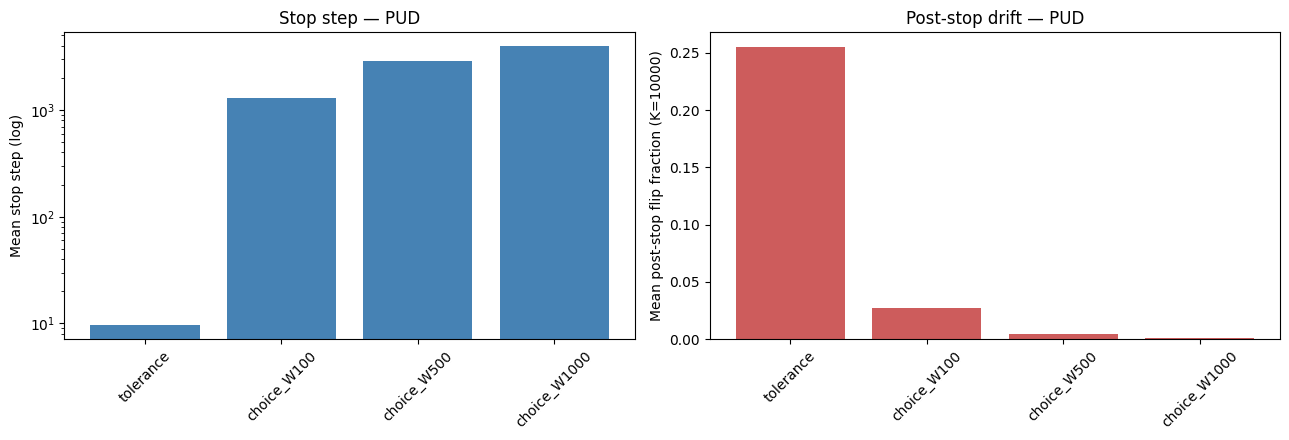

In [114]:
print("=== Stopping Comparison: PUD Network ===")
cmp_pud = run_comparison(G_pud, "PUD", "pud")

## Tobacco Network

=== Stopping Comparison: Tobacco Network ===


[Tobacco] criteria:   0%|          | 0/4 [00:00<?, ?it/s]

  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/tobacco_stopping_comparison.csv (400 rows)
   criterion  mean_stop  mean_truth  mean_flip  any_flip_rate
   tolerance      12.77    0.563599   0.325571           1.00
 choice_W100    2207.05    0.869446   0.008962           0.89
 choice_W500    4332.41    0.876782   0.001592           0.32
choice_W1000    5840.90    0.877647   0.000727           0.19


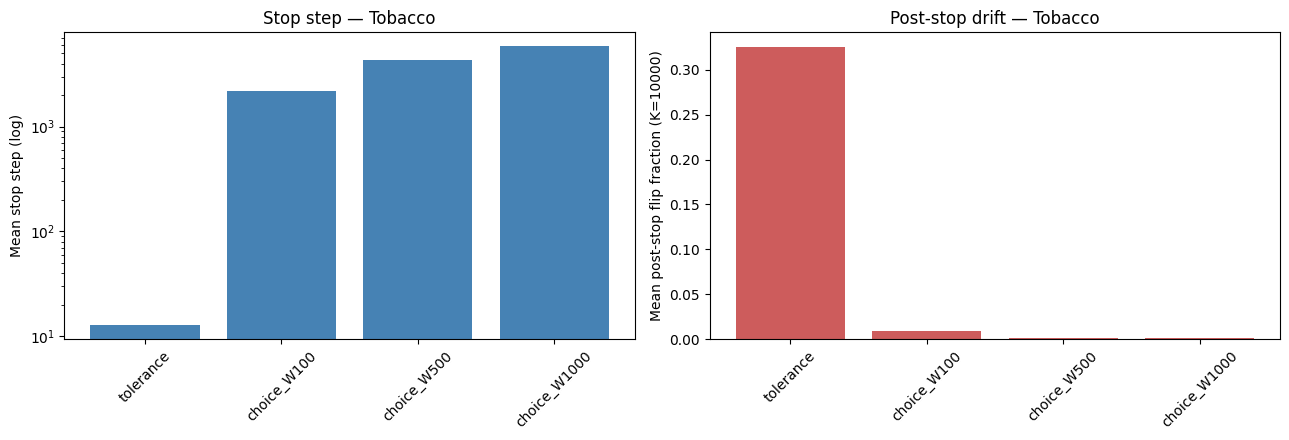

In [115]:
print("=== Stopping Comparison: Tobacco Network ===")
cmp_tobacco = run_comparison(G_tobacco, "Tobacco", "tobacco")

## Ego Network

=== Stopping Comparison: Ego Network ===


[Ego] criteria:   0%|          | 0/4 [00:00<?, ?it/s]

  Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/choice_stability_study/full/ego_stopping_comparison.csv (400 rows)
   criterion  mean_stop  mean_truth  mean_flip  any_flip_rate
   tolerance      12.95    0.539026   0.459264           1.00
 choice_W100    2633.36    0.993221   0.005010           0.89
 choice_W500    5083.69    0.997416   0.000795           0.31
choice_W1000    6970.09    0.997913   0.000278           0.13


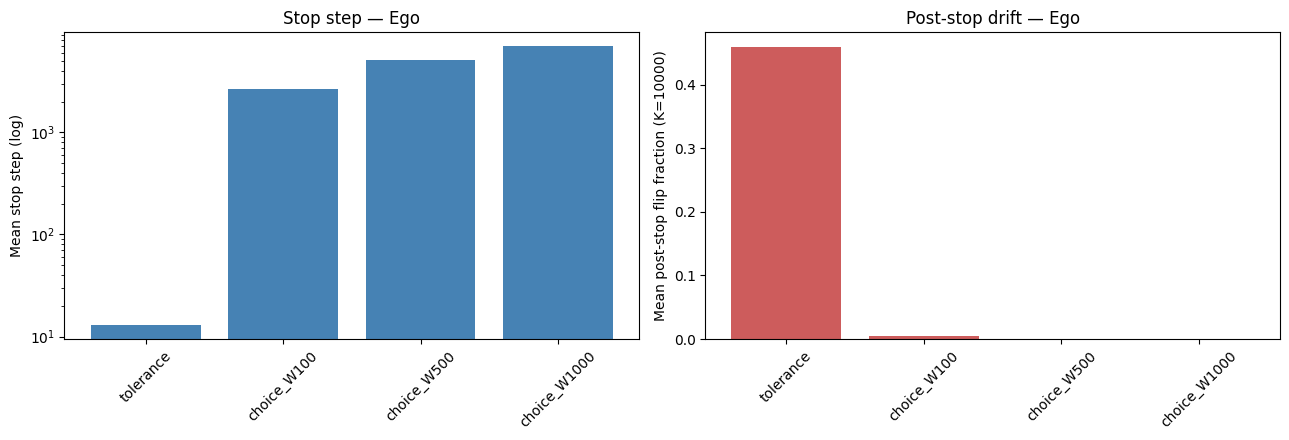

In [116]:
print("=== Stopping Comparison: Ego Network ===")
cmp_ego = run_comparison(G_ego, "Ego", "ego")

# Disconnect from Runtime

In [117]:
# Release the Colab runtime last (no-op locally). Print before disconnecting.
if not RUNNING_LOCALLY:
    from datetime import datetime
    import pytz
    from IPython.display import Javascript
    stamp = datetime.now(pytz.timezone('America/New_York')).strftime('%Y-%m-%d %H:%M:%S %Z')
    print(f"✅ Finished at {stamp} — disconnecting runtime.")
    display(Javascript('google.colab.kernel.disconnect()'))
else:
    print("Local run complete (runtime not disconnected).")

✅ Finished at 2026-07-18 21:53:56 EDT — disconnecting runtime.


<IPython.core.display.Javascript object>